In [9]:
import os
os.environ["CRDS_PATH"] = os.path.expanduser("~/crds_cache")
os.makedirs(os.environ["CRDS_PATH"], exist_ok=True)

os.environ["CRDS_SERVER_URL"] = "https://jwst-crds.stsci.edu"
os.environ["CRDS_CONTEXT"] = "jwst_1460.pmap"

from astropy.table import Table
import numpy as np
import matplotlib.pyplot as plt
import astropy.units as u
from astroquery.svo_fps import SvoFps
from astropy.wcs import WCS
from astropy.io import fits
from dust_extinction.averages import RL85_MWGC
from dust_extinction.parameter_averages import CCM89

def get_mag(catalog, ww, filtername='f140m' ):
    print(ww.proj_plane_pixel_area())
    
    flux= (catalog['flux_fit_' + filtername] * u.MJy/u.sr * ww.proj_plane_pixel_area()).to(u.Jy)
    eflux_jy = (catalog['flux_err_' + filtername] * u.MJy/u.sr *  ww.proj_plane_pixel_area()).to(u.Jy)

    jfilts = SvoFps.get_filter_list('JWST')
    jfilts.add_index('filterID')
    wav = int(filtername[1:-1])

    zeropoint_ab = 3631 * u.Jy  # Default to AB magnitude zero point
 
    if wav < 500:

        zeropoint_vega = u.Quantity(jfilts.loc[f'JWST/NIRCam.{filtername.upper()}']['ZeroPoint'], u.Jy)
    else:
        zeropoint_vega = u.Quantity(jfilts.loc[f'JWST/MIRI.{filtername.upper()}']['ZeroPoint'], u.Jy)
   
    abmag = -2.5 * np.log10(flux / zeropoint_ab) * u.mag
    abmag_err = 2.5 / np.log(10) * np.abs(eflux_jy / flux) * u.mag

    vegamag = -2.5 * np.log10(flux / zeropoint_vega) * u.mag
    vegamag_err = 2.5 / np.log(10) * np.abs(eflux_jy / flux) * u.mag

    return  vegamag, vegamag_err, abmag, abmag_err



catalog = Table.read('/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/catalogs/final_catalog.fits')

image_filenames ={
    "f140m": "/orange/adamginsburg/jwst/w51/F140M/pipeline/jw06151-o001_t001_nircam_clear-f140m-merged_i2d.fits",
    "f150w": "/orange/adamginsburg/jwst/w51/F150W/pipeline/jw06151-o001_t001_nircam_clear-f150w-merged_i2d.fits",
    "f162m": "/orange/adamginsburg/jwst/w51/F162M/pipeline/jw06151-o001_t001_nircam_clear-f162m-merged_i2d.fits",
    "f182m": "/orange/adamginsburg/jwst/w51/F182M/pipeline/jw06151-o001_t001_nircam_clear-f182m-merged_i2d.fits",
    "f187n": "/orange/adamginsburg/jwst/w51/F187N/pipeline/jw06151-o001_t001_nircam_clear-f187n-merged_i2d.fits",
    "f210m": "/orange/adamginsburg/jwst/w51/F210M/pipeline/jw06151-o001_t001_nircam_clear-f210m-merged_i2d.fits",
    "f335m": "/orange/adamginsburg/jwst/w51/F335M/pipeline/jw06151-o001_t001_nircam_clear-f335m-merged_i2d.fits",
    "f360m": "/orange/adamginsburg/jwst/w51/F360M/pipeline/jw06151-o001_t001_nircam_clear-f360m-merged_i2d.fits",
    "f405n": "/orange/adamginsburg/jwst/w51/F405N/pipeline/jw06151-o001_t001_nircam_clear-f405n-merged_i2d.fits",
    "f410m": "/orange/adamginsburg/jwst/w51/F410M/pipeline/jw06151-o001_t001_nircam_clear-f410m-merged_i2d.fits", # weird, the filename is different from what is downloaded with the STScI pipeline...
    "f480m": "/orange/adamginsburg/jwst/w51/F480M/pipeline/jw06151-o001_t001_nircam_clear-f480m-merged_i2d.fits",
    "f560w": "/orange/adamginsburg/jwst/w51/F560W/pipeline/jw06151-o002_t001_miri_f560w_i2d.fits",
    "f770w": "/orange/adamginsburg/jwst/w51/F770W/pipeline/jw06151-o002_t001_miri_f770w_i2d.fits",
    "f1000w": "/orange/adamginsburg/jwst/w51/F1000W/pipeline/jw06151-o002_t001_miri_f1000w_i2d.fits",
    "f1280w": "/orange/adamginsburg/jwst/w51/F1280W/pipeline/jw06151-o002_t001_miri_f1280w_i2d.fits",
    "f2100w": "/orange/adamginsburg/jwst/w51/F2100W/pipeline/jw06151-o002_t001_miri_f2100w_i2d.fits",
    
}

f140m_header = fits.getheader(image_filenames['f140m'], ext=('SCI', 1))
f162m_header = fits.getheader(image_filenames['f162m'], ext=('SCI', 1))
f182m_header = fits.getheader(image_filenames['f182m'], ext=('SCI', 1))
f210m_header = fits.getheader(image_filenames['f210m'], ext=('SCI', 1))
f335m_header = fits.getheader(image_filenames['f335m'], ext=('SCI', 1))
f360m_header = fits.getheader(image_filenames['f360m'], ext=('SCI', 1))
f405n_header = fits.getheader(image_filenames['f405n'], ext=('SCI', 1))
f410m_header = fits.getheader(image_filenames['f410m'], ext=('SCI', 1))
f480m_header = fits.getheader(image_filenames['f480m'], ext=('SCI', 1))
f560w_header = fits.getheader(image_filenames['f560w'], ext=('SCI', 1))
f770w_header = fits.getheader(image_filenames['f770w'], ext=('SCI', 1))
f1000w_header = fits.getheader(image_filenames['f1000w'], ext=('SCI', 1))
f1280w_header = fits.getheader(image_filenames['f1280w'], ext=('SCI', 1))
f2100w_header = fits.getheader(image_filenames['f2100w'], ext=('SCI', 1))



f140m_mag = get_mag(catalog, WCS(f140m_header), filtername='f140m')
f162m_mag = get_mag(catalog, WCS(f162m_header), filtername='f162m')
f182m_mag = get_mag(catalog, WCS(f182m_header), filtername='f182m')
f210m_mag = get_mag(catalog, WCS(f210m_header), filtername='f210m')
f335m_mag = get_mag(catalog, WCS(f335m_header), filtername='f335m')
f360m_mag = get_mag(catalog, WCS(f360m_header), filtername='f360m')
f405n_mag = get_mag(catalog, WCS(f405n_header), filtername='f405n')
f410m_mag = get_mag(catalog, WCS(f410m_header), filtername='f410m')
f480m_mag = get_mag(catalog, WCS(f480m_header), filtername='f480m')
f560w_mag = get_mag(catalog, WCS(f560w_header), filtername='f560w')
f770w_mag = get_mag(catalog, WCS(f770w_header), filtername='f770w')
f1000w_mag = get_mag(catalog, WCS(f1000w_header), filtername='f1000w')
f1280w_mag = get_mag(catalog, WCS(f1280w_header), filtername='f1280w')
f2100w_mag = get_mag(catalog, WCS(f2100w_header), filtername='f2100w')

f187n_header = fits.getheader(image_filenames['f187n'], ext=('SCI', 1))
f187n_mag = get_mag(catalog, WCS(f187n_header), filtername='f187n')


from dust_extinction.averages import RL85_MWGC
from dust_extinction.parameter_averages import CCM89

ext = RL85_MWGC()
def plot_extvec_cmd(ax, color1, mag1, ext=RL85_MWGC(), extvec_scale=200, start=None,
                    color='y', head_width=0.5, color1_data=None, mag1_data=None):
    def get_wave(c):
        if c == '410m405': return 4.10*u.um
        if c == '405m410': return 4.05*u.um
        if c == 'Hmag': return 1.634*u.um
        if c == 'Ksmag': return 2.143527*u.um
        return int(c[1:-1])/100*u.um

    w1 = get_wave(color1[0])
    w2 = get_wave(color1[1])
    w3 = get_wave(mag1[0])

    if w1 > w2:
        w1, w2 = w2, w1
        color1 = color1[::-1]
    print(w1,w2,w3)

    # Only plot if all are in valid range
    try:
        e_1 = ext(1/w1) * extvec_scale
        e_2 = ext(1/w2) * extvec_scale
        e_3 = ext(1/w3) * extvec_scale
    except ValueError as e:
        print(f"Extinction vector not plotted: {e}")
        return
    print(w1,w2,w3)
    print(e_1, e_2, e_3)
    if start == None:
        mean_color1 = np.nanmean(color1_data)
        mean_mag1 = np.nanmean(mag1_data)
        std_color1 = np.nanstd(color1_data)
        std_mag1 = np.nanstd(mag1_data)
        if e_1 - e_2 < 0:
            std_color1 *= -1
        
    
        start2 = (mean_color1 + 2*std_color1, mean_mag1 + 2*std_mag1)
    else:
        start2 = start
    
    # Strip units for plotting if present
    if hasattr(start2[0], 'value'):
        start2_x = start2[0].value
        start2_y = start2[1].value
    else:
        start2_x = start2[0]
        start2_y = start2[1]

    ax.annotate(f'$A_V={extvec_scale}$', xy=(start2_x + (e_1 - e_2), start2_y + e_3),
                xytext=(start2_x, start2_y),
                arrowprops=dict(arrowstyle='-|>', color=color,
                                shrinkA=0, shrinkB=0,
                                mutation_scale=20, linewidth=1.5))
    ax.plot([], [], color=color, marker='>', markersize=8,
            label=f'$A_V={extvec_scale}$', linestyle='-', linewidth=2)


imgsavedir = '/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/plots/cmds/'
filters = {
    'f140m': f140m_mag,
    'f162m': f162m_mag,
    'f182m': f182m_mag,
    'f187n': f187n_mag,
    'f210m': f210m_mag,
    'f335m': f335m_mag,
    'f360m': f360m_mag,
    'f405n': f405n_mag,
    'f410m': f410m_mag,
    'f480m': f480m_mag,
    'f560w': f560w_mag,
    'f770w': f770w_mag,
    'f1000w': f1000w_mag,
    'f1280w': f1280w_mag,
    'f2100w': f2100w_mag,
}
filter_names = list(filters.keys())

def get_line_excess(catalog, narrow, wide):
    ww_narrow = WCS(fits.getheader(image_filenames[narrow], ext=('SCI', 1)))
    ww_wide = WCS(fits.getheader(image_filenames[wide], ext=('SCI', 1)))
    data_narrow = (catalog['flux_fit_' + narrow] * u.MJy/u.sr * ww_narrow.proj_plane_pixel_area()).to(u.Jy)
    data_wide = (catalog['flux_fit_' + wide] * u.MJy/u.sr * ww_wide.proj_plane_pixel_area()).to(u.Jy)

    wavelength_table_narrow = SvoFps.get_transmission_data(f'JWST/NIRCAM.{narrow}')
    wavelength_table_wide = SvoFps.get_transmission_data(f'JWST/NIRCAM.{wide}')

    waves_wide = wavelength_table_wide['Wavelength']
    trans_narrow = np.interp(waves_wide, wavelength_table_narrow['Wavelength'], wavelength_table_narrow['Transmission'])
    trans_wide = wavelength_table_wide['Transmission']


    fractional_bandwidth = ( (trans_wide/trans_wide.max()) * (trans_narrow/trans_narrow.max()) ).sum() / (trans_wide/trans_wide.max()).sum()
    print(f'Fractional bandwidth: {fractional_bandwidth}')
    if fractional_bandwidth == 1:
        print("The filters either have no overlap or are identical. Exiting")
        return


    wide_minus_narrow = (data_wide - data_narrow * fractional_bandwidth) / (1-fractional_bandwidth)
    #return wide_minus_narrow

    narrow_minus_wide = data_narrow - wide_minus_narrow
    #narrow_minus_wide = (data_narrow - data_wide * fractional_bandwidth) / (1-fractional_bandwidth)
    return np.array(narrow_minus_wide)  # Ensure writable copy

paa_excess = get_line_excess(catalog, 'f187n', 'f182m')
bra_excess = get_line_excess(catalog, 'f405n', 'f410m')

print('paa_excess', paa_excess)



'datfix' made the change 'Set DATE-BEG to '2025-05-06T16:37:42.537' from MJD-BEG.
Set DATE-AVG to '2025-05-06T16:59:22.406' from MJD-AVG.
Set DATE-END to '2025-05-06T17:21:22.408' from MJD-END'.
'obsfix' made the change 'Set OBSGEO-L to  -106.570116 from OBSGEO-[XYZ].
Set OBSGEO-B to   -25.271881 from OBSGEO-[XYZ].
Set OBSGEO-H to 1611441536.798 from OBSGEO-[XYZ]'.
'datfix' made the change 'Set DATE-BEG to '2025-05-06T13:57:33.059' from MJD-BEG.
Set DATE-AVG to '2025-05-06T14:19:06.870' from MJD-AVG.
Set DATE-END to '2025-05-06T14:41:02.194' from MJD-END'.
'obsfix' made the change 'Set OBSGEO-L to  -106.647326 from OBSGEO-[XYZ].
Set OBSGEO-B to   -25.220336 from OBSGEO-[XYZ].
Set OBSGEO-H to 1610512569.543 from OBSGEO-[XYZ]'.
'datfix' made the change 'Set DATE-BEG to '2025-05-06T14:49:48.239' from MJD-BEG.
Set DATE-AVG to '2025-05-06T15:11:59.611' from MJD-AVG.
Set DATE-END to '2025-05-06T15:35:36.878' from MJD-END'.
'obsfix' made the change 'Set OBSGEO-L to  -106.622086 from OBSGEO-[X

7.525093724479512e-11 deg2
7.52790883669383e-11 deg2
7.52510476872822e-11 deg2
7.52514718037244e-11 deg2
3.053877779107583e-10 deg2
3.0536898714608487e-10 deg2
3.056563930691893e-10 deg2
3.0541063885182936e-10 deg2
3.054668262896466e-10 deg2
9.491459138193236e-10 deg2
9.49145905084584e-10 deg2
9.491458943030916e-10 deg2
9.49145885655769e-10 deg2
9.491458757317268e-10 deg2
7.524574264515582e-11 deg2


'datfix' made the change 'Set DATE-BEG to '2025-05-06T15:43:50.732' from MJD-BEG.
Set DATE-AVG to '2025-05-06T16:06:02.828' from MJD-AVG.
Set DATE-END to '2025-05-06T16:29:39.435' from MJD-END'.
'obsfix' made the change 'Set OBSGEO-L to  -106.596047 from OBSGEO-[XYZ].
Set OBSGEO-B to   -25.254571 from OBSGEO-[XYZ].
Set OBSGEO-H to 1611129611.449 from OBSGEO-[XYZ]'.
'datfix' made the change 'Set DATE-BEG to '2025-05-06T16:37:42.537' from MJD-BEG.
Set DATE-AVG to '2025-05-06T16:59:22.421' from MJD-AVG.
Set DATE-END to '2025-05-06T17:21:22.408' from MJD-END'.
'obsfix' made the change 'Set OBSGEO-L to  -106.570116 from OBSGEO-[XYZ].
Set OBSGEO-B to   -25.271881 from OBSGEO-[XYZ].
Set OBSGEO-H to 1611441536.798 from OBSGEO-[XYZ]'.
'datfix' made the change 'Set DATE-BEG to '2024-09-08T10:10:19.109' from MJD-BEG.
Set DATE-AVG to '2024-09-08T11:22:58.102' from MJD-AVG.
Set DATE-END to '2024-09-08T12:35:44.015' from MJD-END'.
'obsfix' made the change 'Set OBSGEO-L to   -34.699734 from OBSGEO-[X

Fractional bandwidth: 0.09655212419159323
Fractional bandwidth: 0.1027882360899125
paa_excess [8.28595832e-09            nan 4.42807917e-07 ...            nan
            nan            nan]


'datfix' made the change 'Set DATE-BEG to '2025-05-06T14:49:48.239' from MJD-BEG.
Set DATE-AVG to '2025-05-06T15:11:59.611' from MJD-AVG.
Set DATE-END to '2025-05-06T15:35:36.878' from MJD-END'.
'obsfix' made the change 'Set OBSGEO-L to  -106.622086 from OBSGEO-[XYZ].
Set OBSGEO-B to   -25.237189 from OBSGEO-[XYZ].
Set OBSGEO-H to 1610816321.821 from OBSGEO-[XYZ]'.
'datfix' made the change 'Set DATE-BEG to '2025-05-06T13:02:15.381' from MJD-BEG.
Set DATE-AVG to '2025-05-06T13:24:26.757' from MJD-AVG.
Set DATE-END to '2025-05-06T13:48:04.021' from MJD-END'.
'obsfix' made the change 'Set OBSGEO-L to  -106.673970 from OBSGEO-[XYZ].
Set OBSGEO-B to   -25.202550 from OBSGEO-[XYZ].
Set OBSGEO-H to 1610191894.941 from OBSGEO-[XYZ]'.
'datfix' made the change 'Set DATE-BEG to '2025-05-06T15:43:50.732' from MJD-BEG.
Set DATE-AVG to '2025-05-06T16:06:02.828' from MJD-AVG.
Set DATE-END to '2025-05-06T16:29:39.435' from MJD-END'.
'obsfix' made the change 'Set OBSGEO-L to  -106.596047 from OBSGEO-[X

### F140M - F162M vs F140M color coded by F405N-F410M

1.4 um 1.62 um 1.4 um
1.4 um 1.62 um 1.4 um
7.0412946428571415 5.4357638888888875 7.0412946428571415


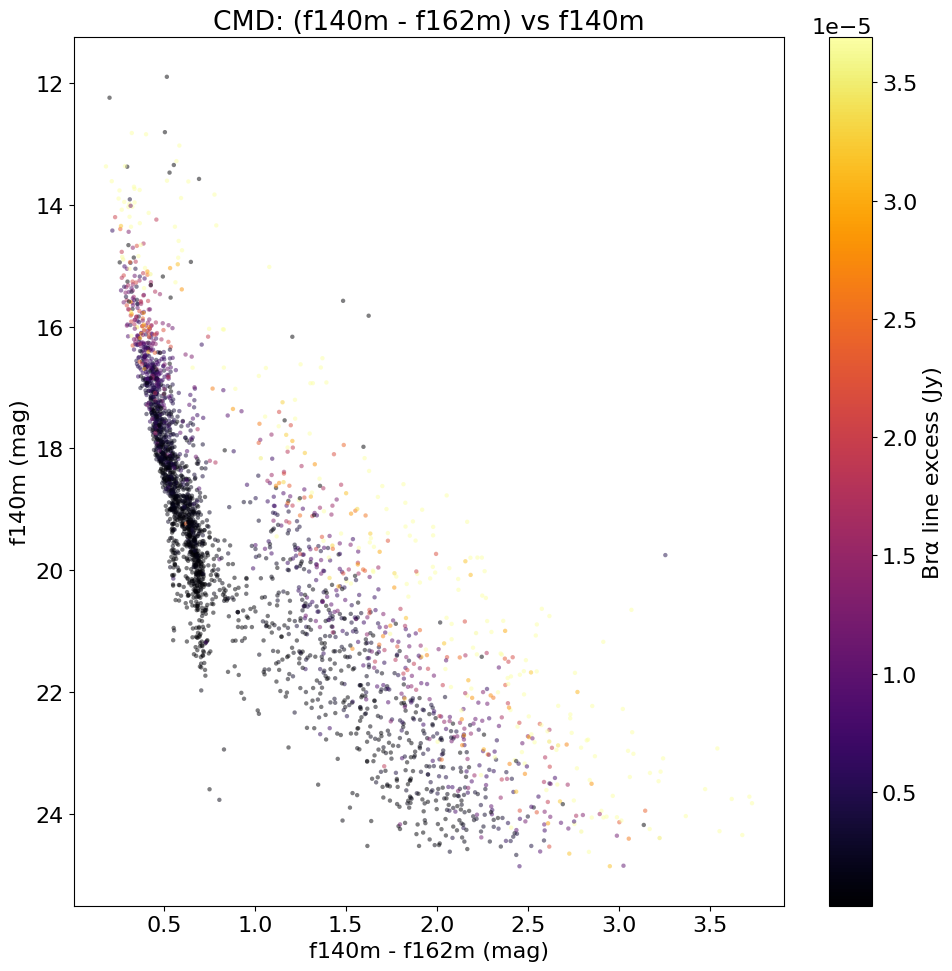

In [10]:
# plot f140m-f162m color coded by f405n-f410m color
color = filters['f140m'][0] - filters['f162m'][0]
color_for_points = bra_excess

magnitude = filters['f140m'][0]


# Create plot
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111)

#hb = ax.hexbin(color_valid, mag_valid, gridsize=100, cmap='inferno', mincnt=1, bins='log')
#cb = fig.colorbar(hb, ax=ax, label='log(N)')
cmap = plt.get_cmap('inferno')

ax.scatter(color.value, magnitude.value, s=10, c=color_for_points, cmap=cmap, alpha=0.5, edgecolor='none',vmin=np.nanpercentile(color_for_points, 10), vmax=np.nanpercentile(color_for_points, 90))
ax.set_xlabel('f140m - f162m (mag)')
ax.set_ylabel('f140m (mag)')
ax.set_title(f'CMD: (f140m - f162m) vs f140m')
ax.invert_yaxis()  # Invert y-axis for magnitude

# Add extinction vector
plot_extvec_cmd(ax, color1=('f140m', 'f162m'), mag1=('f140m',), 
                ext=ext, extvec_scale=30, color='r', 
                color1_data=color, mag1_data=magnitude)
#add colorbar for the color coding
norm = plt.Normalize(vmin=np.nanpercentile(color_for_points, 10), vmax=np.nanpercentile(color_for_points, 90))
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label('Brα line excess (Jy)')
plt.tight_layout()
#plt.savefig(f'{imgsavedir}cmd_{f1}_{f2}_vs_{mag_filter}.png', dpi=150)
plt.show()

1.4 um 1.62 um 1.4 um
1.4 um 1.62 um 1.4 um
7.0412946428571415 5.4357638888888875 7.0412946428571415


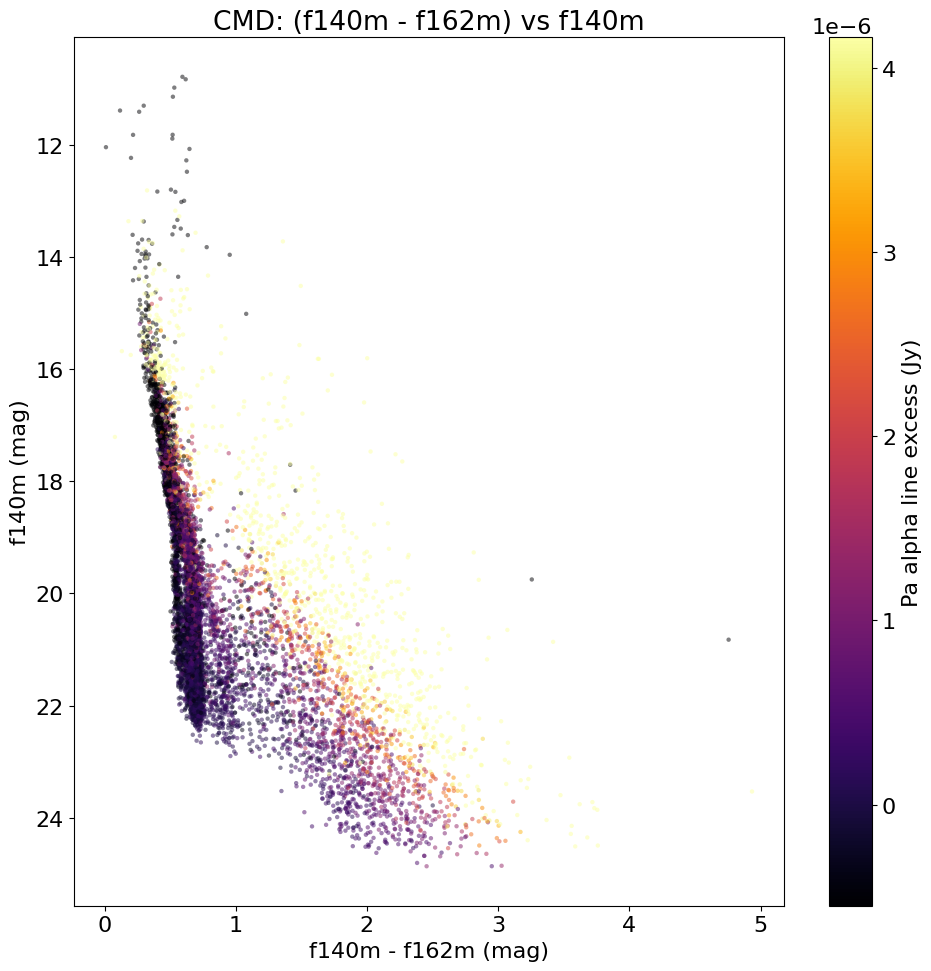

In [11]:
#plot the same for f187n-f182m excess
color_for_points = paa_excess
magnitude = filters['f140m'][0]


# Create plot
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111)

#hb = ax.hexbin(color_valid, mag_valid, gridsize=100, cmap='inferno', mincnt=1, bins='log')
#cb = fig.colorbar(hb, ax=ax, label='log(N)')
cmap = plt.get_cmap('inferno')

ax.scatter(color.value, magnitude.value, s=10, c=color_for_points, cmap=cmap, alpha=0.5, edgecolor='none',vmin=np.nanpercentile(color_for_points, 10), vmax=np.nanpercentile(color_for_points, 90))
ax.set_xlabel('f140m - f162m (mag)')
ax.set_ylabel('f140m (mag)')
ax.set_title(f'CMD: (f140m - f162m) vs f140m')
ax.invert_yaxis()  # Invert y-axis for magnitude

# Add extinction vector
plot_extvec_cmd(ax, color1=('f140m', 'f162m'), mag1=('f140m',), 
                ext=ext, extvec_scale=30, color='r', 
                color1_data=color, mag1_data=magnitude)
#add colorbar for the color coding
norm = plt.Normalize(vmin=np.nanpercentile(color_for_points, 10), vmax=np.nanpercentile(color_for_points, 90))
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label('Pa alpha line excess (Jy)')
plt.tight_layout()
#plt.savefig(f'{imgsavedir}cmd_{f1}_{f2}_vs_{mag_filter}.png', dpi=150)
plt.show()

In [12]:
from astropy import units as u
from astropy import constants
from sensitivity import cardelli_law
from pyspeckit.spectrum.models import hydrogen
from hii_sensitivity import ha_to_hb_1e4, paa_to_hb_1e4, bra_to_hgamma_1e4, pab_to_hgamma_1e4, hg_to_hb_1e4, wl_paa
from astroquery.svo_fps import SvoFps

wl_bra = hydrogen.wavelength['bracketta']*u.um
twomass = SvoFps.get_filter_list('2MASS')
wl_Ks = twomass[twomass['filterID'].astype(str)=='2MASS/2MASS.Ks']['WavelengthCen'][0] * u.AA
def lacc(mdot, rstar=u.R_sun, mstar=u.M_sun):
    # Alcala+ 2017 eqn 1
    # 1.25 comes from assuming r_inner disk = 5 r_star
    return (mdot / 1.25 * constants.G * mstar / rstar).to(u.L_sun)
def log_pab(lacc):
    # from table B1 of Alcala+2017:
    # log L_acc = 1.06 log L_pab + 2.76
    # so
    # log L_pab = (log L_acc - 2.76) / 1.06
    return 1/1.06 * np.log10(lacc/u.L_sun) - 2.76/1.06

def log_paa(lacc):
    # pab * (paa / hb) * (hb / hg) *  (hg / pab)
    return log_pab(lacc) + np.log10(paa_to_hb_1e4 / hg_to_hb_1e4 / pab_to_hgamma_1e4)

def log_bra(lacc):
    # brackett alpha prediction from PaB (could use BrG too...)
    return log_pab(lacc) + np.log10(bra_to_hgamma_1e4 / pab_to_hgamma_1e4)

def L_paa(lacc):
    return 10**log_paa(lacc) * u.L_sun

def L_bra(lacc):
    return 10**log_bra(lacc) * u.L_sun

def S_paa(lacc, distance=5.4*u.kpc, A_K=0):
    A_paa = (cardelli_law(wl_paa) / cardelli_law(wl_Ks)) * A_K
    attenuation = 10**(-A_paa / 2.5)
    return (L_paa(lacc) / (4*np.pi*distance**2)).to(u.erg/u.s/u.cm**2) * attenuation

def S_bra(lacc, distance=5.4*u.kpc, A_K=0):
    A_bra = (cardelli_law(wl_bra) / cardelli_law(wl_Ks)) * A_K
    attenuation = 10**(-A_bra / 2.5)
    return (L_bra(lacc) / (4*np.pi*distance**2)).to(u.erg/u.s/u.cm**2) * attenuation

#lacc_vals = lacc(mdot)
#spaa = S_paa(lacc_vals, distance=5.4*u.kpc)
#sbra = S_bra(lacc_vals, distance=5.4*u.kpc)

#get the inverse
def macc(Ldot, rstar=u.R_sun, mstar=u.M_sun):
    # Invert the lacc equation to get macc
    return (Ldot * 1.25 * rstar / (constants.G * mstar)).to(u.M_sun/u.yr)
def Lbra_to_lacc(L_bra):
    loglacc = 1.06*(np.log10(L_bra/u.L_sun) +2.76/1.06 - np.log10(paa_to_hb_1e4 / hg_to_hb_1e4 / pab_to_hgamma_1e4))
    return 10**loglacc * u.L_sun
def Lpaa_to_lacc(L_paa):
    loglacc = 1.06*(np.log10(L_paa/u.L_sun) +2.76/1.06 - np.log10(bra_to_hgamma_1e4 / pab_to_hgamma_1e4))
    return 10**loglacc * u.L_sun

def S_paa_to_lacc(S_paa, distance=5.4*u.kpc, A_K=0):
    # Invert the S_paa equation to get lacc
    A_paa = (cardelli_law(wl_paa) / cardelli_law(wl_Ks)) * A_K
    attenuation = 10**(-A_paa / 2.5)
    L_paa = (S_paa * 4*np.pi*distance**2 / attenuation).to(u.L_sun)
    L_acc = Lbra_to_lacc(L_paa)
    return L_acc


def S_bra_to_lacc(S_bra, distance=5.4*u.kpc, A_K=0):
    # Invert the S_bra equation to get lacc
    A_bra = (cardelli_law(wl_bra) / cardelli_law(wl_Ks)) * A_K
    attenuation = 10**(-A_bra / 2.5)
    L_bra = (S_bra * 4*np.pi*distance**2 / attenuation).to(u.L_sun)
    L_acc = Lbra_to_lacc(L_bra)
    return L_acc

 col1    col2    col3       col4          col5       col6   col7   col8   col9 col10 col11 col12  col13 col14 col15 col16 col17 col18   col19   col20  col21   col22    col23     col24     col25   col26   col27   col28  col29  col30  col31  col32  col33  col34  col35  col36  col37  col38  col39  col40  col41  col42  col43  col44  col45  col46  col47  col48  col49  col50 
------ ------- ------- -------------- ------------ ------- ------ ------ ----- ----- ----- ------ ----- ----- ----- ----- ----- ----- --------- ----- -------- ------ --------- --------- --------- ------ ------- ------- ------ ------ ------ ------ ------ ------ ------ ------ ------ ------ ------ ------ ------ ------ ------ ------ ------ ------ ------ ------ ------ ------
0.0207 0.15867     6.0   0.0908484459 1.0897678296   0.091  -1.33 3.4326 3.409     0   0.0  0.545   0.0   0.0   0.0   0.0   0.0    -1 -3.89e-14   0.0   0.6936 0.2855  0.003749  0.001011  0.009172   -1.0 0.02085   8.095  9.712  7.478  6.249  5.749  5.324 

(25.0, 8.0)

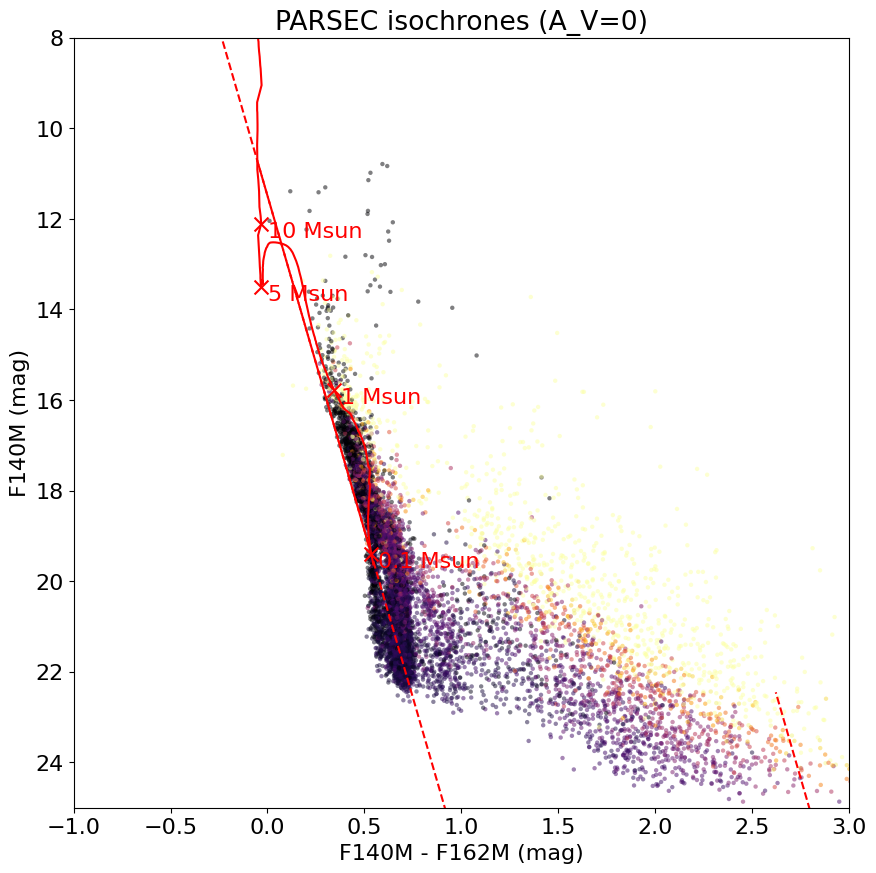

In [13]:
from astropy.table import Table
import crds
parsec_av0 = Table.read('/home/t.yoo/parsec_av0.txt', format='ascii')
parsec_av0.pprint(max_width=-1, max_lines=-1)   
m_init = parsec_av0['col4']  
parsec_av0 = parsec_av0[m_init<300]              
logage_av0 = parsec_av0['col3']
mass_av0 = parsec_av0['col6']
print(np.min(m_init), np.max(m_init))
print(np.min(mass_av0), np.max(mass_av0))
F140Mmag_av0 = parsec_av0['col39'] + 5*np.log10(5400)-5
F162Mmag_av0 = parsec_av0['col40']+ 5*np.log10(5400)-5
F182Mmag_av0 = parsec_av0['col41']+ 5*np.log10(5400)-5
F210Mmag_av0 = parsec_av0['col42']+ 5*np.log10(5400)-5
F335Mmag_av0 = parsec_av0['col45']+ 5*np.log10(5400)-5
F360Mmag_av0 = parsec_av0['col46']+ 5*np.log10(5400)-5
F410Mmag_av0 = parsec_av0['col47']+ 5*np.log10(5400)-5
F480Mmag_av0 = parsec_av0['col50']+ 5*np.log10(5400)-5


fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111)
age_idx = logage_av0 == 6

ax.plot(F140Mmag_av0[age_idx] - F162Mmag_av0[age_idx], F140Mmag_av0[age_idx], color='r', label='PARSEC isochrones (A_V=0)')
# also draw a single line connecting the first and the last point of the isochrone
idx_01msun = np.argmin(np.abs(mass_av0[age_idx]-0.1))
idx_20msun = np.argmin(np.abs(mass_av0[age_idx]-20))
ax.scatter(color.value, magnitude.value, s=10, c=color_for_points, cmap=cmap, alpha=0.5, edgecolor='none',vmin=np.nanpercentile(color_for_points, 10), vmax=np.nanpercentile(color_for_points, 90))

isochrone_x_start = F140Mmag_av0[age_idx][idx_01msun] - F162Mmag_av0[age_idx][idx_01msun]
isochrone_x_end = F140Mmag_av0[age_idx][idx_20msun] - F162Mmag_av0[age_idx][idx_20msun]
isocrhone_y_start = F140Mmag_av0[age_idx][idx_01msun]
isocrhone_y_end = F140Mmag_av0[age_idx][idx_20msun]

A_K_scale = 5
A_V_scale = A_K_scale * 10
ax.plot([isochrone_x_start, isochrone_x_end], [isocrhone_y_start, isocrhone_y_end], color='r', linestyle='--')
ax.plot([isochrone_x_start+(ext(1/1.4/u.um)-ext(1/1.62/u.um))*A_V_scale, isochrone_x_end+(ext(1/1.4/u.um)-ext(1/1.62/u.um))*A_V_scale], 
[isocrhone_y_start+(ext(1/1.4/u.um))*A_V_scale, isocrhone_y_end+(ext(1/1.4/u.um))*A_V_scale], color='r', linestyle='--')
# extrapolate the linear part of the isochrone to the left and right by 0.5 mag in color
color_slope = (isocrhone_y_end - isocrhone_y_start) / (isochrone_x_end - isochrone_x_start)
color_intercept = isocrhone_y_start - color_slope * isochrone_x_start
# and plot
x_vals = np.array([-1, 4])
y_vals = color_slope * x_vals + color_intercept
ax.plot(x_vals, y_vals, color='r', linestyle='--')

#mark isochrone point where mass = 0.1Msun, 1Msun, 5Msun, 10Msun
for mass in [0.1, 1, 5, 10]:
    idx_mass = np.argmin(np.abs(mass_av0[age_idx]-mass))
    ax.scatter(F140Mmag_av0[age_idx][idx_mass] - F162Mmag_av0[age_idx][idx_mass], F140Mmag_av0[age_idx][idx_mass], color='r', marker='x', s=100, label=f'{mass} Msun')
    ax.annotate(f'{mass} Msun', (F140Mmag_av0[age_idx][idx_mass] - F162Mmag_av0[age_idx][idx_mass], F140Mmag_av0[age_idx][idx_mass]), textcoords="offset points", xytext=(5,-10), ha='left', color='r')
ax.set_xlabel('F140M - F162M (mag)')
ax.set_ylabel('F140M (mag)')
ax.set_title('PARSEC isochrones (A_V=0)')

ax.set_xlim(-1,3)
ax.set_ylim(25, 8)


w_color1_1: 1.4 um w_color1_2: 1.62 um w_mag1: 1.4 um


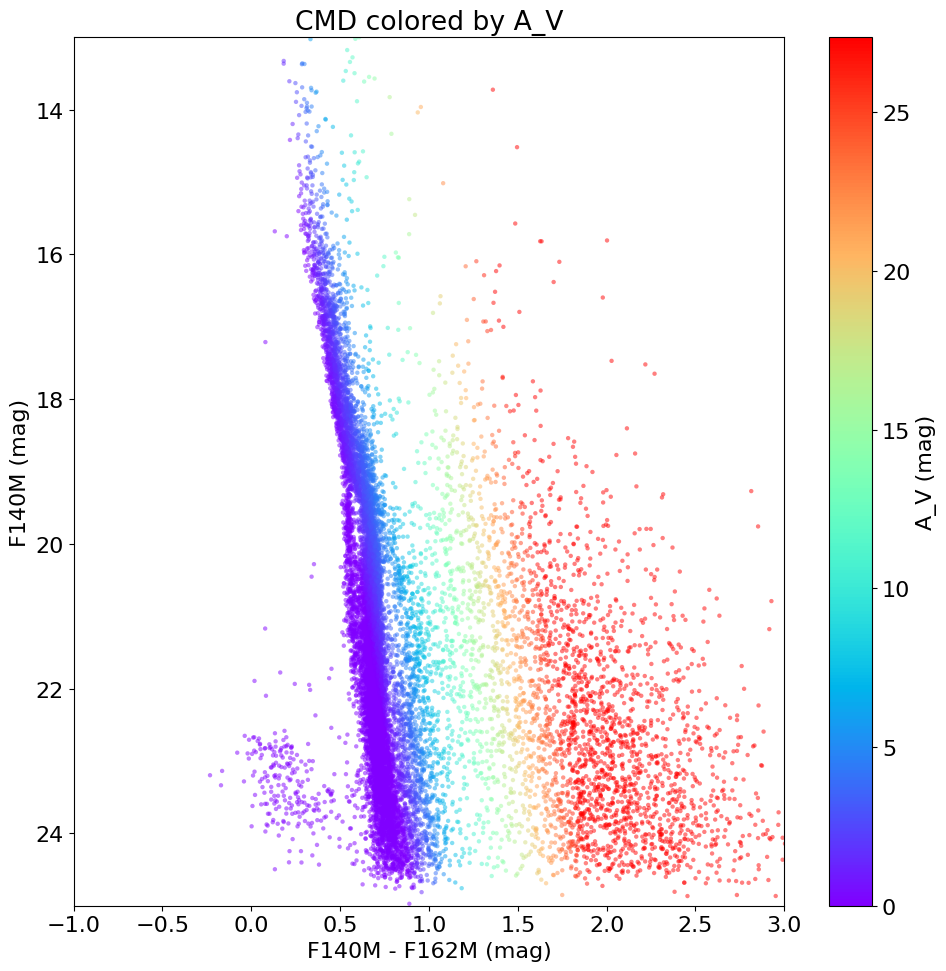

In [14]:
# get A_V for each source by measuring the distance to the isochrone fiducial line along the extinction vector
# if source lies on the negative side of the isochrone, assign A_V=0
def get_av(color, mag, ext=RL85_MWGC(), color1=('f140m', 'f162m'), mag1=('f140m',), isochrone_line_params=(color_slope, color_intercept)):
    # Get the slope and intercept of the isochrone line
    m_iso, b_iso = isochrone_line_params

    # Get the extinction vector components
    w_color1_1 = int(color1[0][1:-1])/100*u.um
    w_color1_2 = int(color1[1][1:-1])/100*u.um
    w_mag1 = int(mag1[0][1:-1])/100*u.um
    print('w_color1_1:', w_color1_1, 'w_color1_2:', w_color1_2, 'w_mag1:', w_mag1)

    e_color1_1 = ext(1/w_color1_1)
    e_color1_2 = ext(1/w_color1_2)
    e_mag1 = ext(1/w_mag1)

    # get the contact to the isochrone line along the extinction vector
    # the extinction vector can be represented as a line with slope m_ext = e_mag1 / (e_color1_1 - e_color1_2) and passing through the point (color, mag)
    m_ext = e_mag1 / (e_color1_1 - e_color1_2)
    b_ext = mag - m_ext * color

    # find the intersection of the isochrone line and the extinction vector
    x_int = (b_ext - b_iso) / (m_iso - m_ext)
    y_int = m_iso * x_int + b_iso

    # calculate A_V as the distance from (color, mag) to (x_int, y_int) along the extinction vector
    av = (mag - y_int) / ext(1/w_mag1)
    av[av < 0] = 0
    return av
def get_mass(color, mag, isochrone_color, isochrone_mag, mass_iso, ext=RL85_MWGC(), color1=('f140m', 'f162m'), mag1=('f140m',), isochrone_line_params=(color_slope, color_intercept)):
    # make a straight line along dust extinction vector and find the intersection with the isochrone, then assign mass based on the isochrone mass at that point
    # the extinction vector can be represented as a line with slope m_ext = e_mag1 / (e_color1_1 - e_color1_2) and passing through the point (color, mag)
    w_color1_1 = int(color1[0][1:-1])/100*u.um
    w_color1_2 = int(color1[1][1:-1])/100*u.um
    w_mag1 = int(mag1[0][1:-1])/100*u.um
    e_color1_1 = ext(1/w_color1_1)
    e_color1_2 = ext(1/w_color1_2)
    e_mag1 = ext(1/w_mag1)
    m_ext = e_mag1 / (e_color1_1 - e_color1_2)
    b_ext = mag - m_ext * color 
    # find the intersection with the isochrone, which can be represented as a line with slope m_iso and intercept b_iso
    m_iso, b_iso = color_slope, color_intercept
    x_int = (b_ext - b_iso) / (m_iso - m_ext)
    y_int = m_iso * x_int + b_iso
    # find the closest point on the isochrone to (x_int, y_int). x_init and y_init are arrays
    massarr = []
    for x, y in zip(x_int, y_int):
        dist = np.sqrt((isochrone_color - x)**2 + (isochrone_mag - y)**2)
        idx_closest = np.argmin(dist)
        massarr.append(mass_iso[idx_closest])
    return np.array(massarr)
av_values = get_av(color.value, magnitude.value, ext=ext, color1=('f140m', 'f162m'), mag1=('f140m',), isochrone_line_params=(color_slope, color_intercept))
mass_values = get_mass(color.value, magnitude.value, isochrone_color=F140Mmag_av0 - F162Mmag_av0, isochrone_mag=F140Mmag_av0, mass_iso=mass_av0)
# plot the same CMD but color code by A_V
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111)
cmap = plt.get_cmap('rainbow')
ax.scatter(color.value, magnitude.value, s=10, c=av_values, cmap=cmap, alpha=0.5, edgecolor='none', vmin=np.nanpercentile(av_values, 10), vmax=np.nanpercentile(av_values, 90))
ax.set_xlabel('F140M - F162M (mag)')
ax.set_ylabel('F140M (mag)')
ax.set_title('CMD colored by A_V')  
ax.set_xlim(-1,3)
ax.set_ylim(25, 13)
# add colorbar for A_V
norm = plt.Normalize(vmin=np.nanpercentile(av_values, 10), vmax=np.nanpercentile(av_values, 90))
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label('A_V (mag)')
plt.tight_layout()

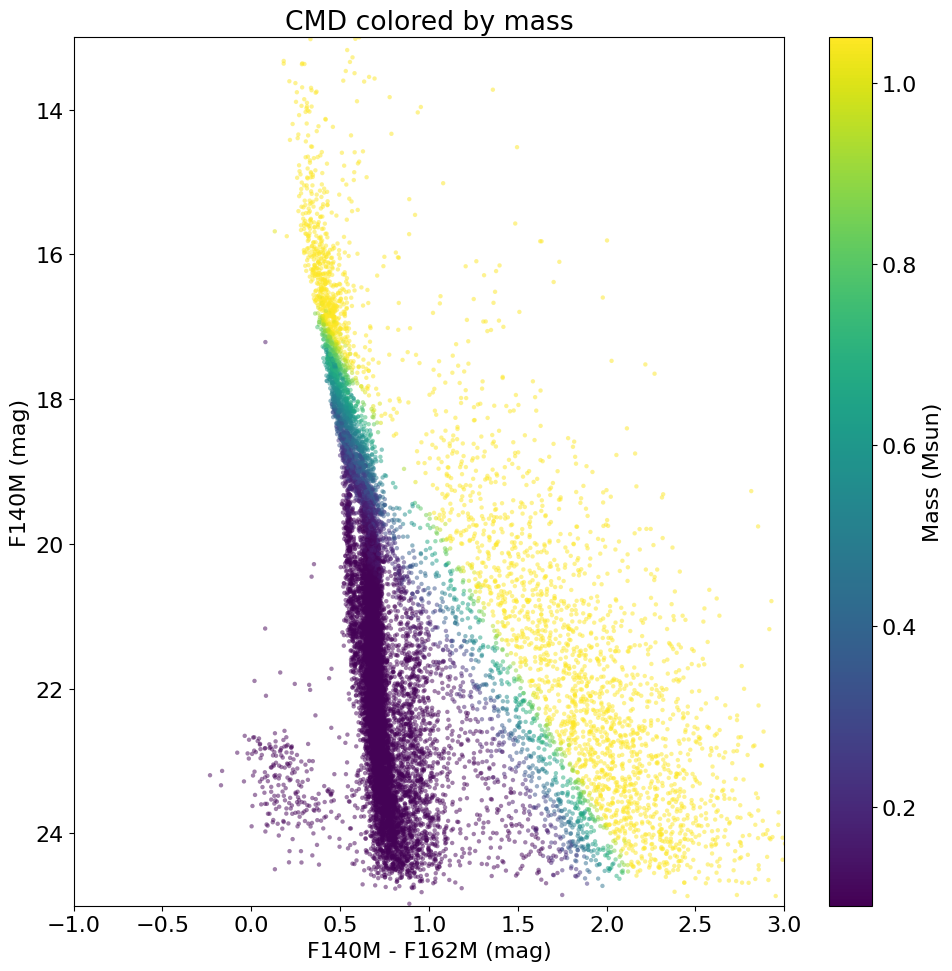

In [15]:
# plot the CMD colored by mass
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111)
cmap = plt.get_cmap('viridis')
ax.scatter(color.value, magnitude.value, s=10, c=mass_values, cmap=cmap, alpha=0.5, edgecolor='none', vmin=np.nanpercentile(mass_values, 10), vmax=np.nanpercentile(mass_values, 90))
ax.set_xlabel('F140M - F162M (mag)')
ax.set_ylabel('F140M (mag)')
ax.set_title('CMD colored by mass')
ax.set_xlim(-1,3)
ax.set_ylim(25, 13)
# add colorbar for mass
norm = plt.Normalize(vmin=np.nanpercentile(mass_values, 10), vmax=np.nanpercentile(mass_values, 90))
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label('Mass (Msun)')
plt.tight_layout()

[8.28595832e-09            nan 4.42807917e-07 ...            nan
            nan            nan]
[1.58616451e-05            nan 2.68534287e-02 ...            nan
            nan            nan] solLum


invalid value encountered in log10


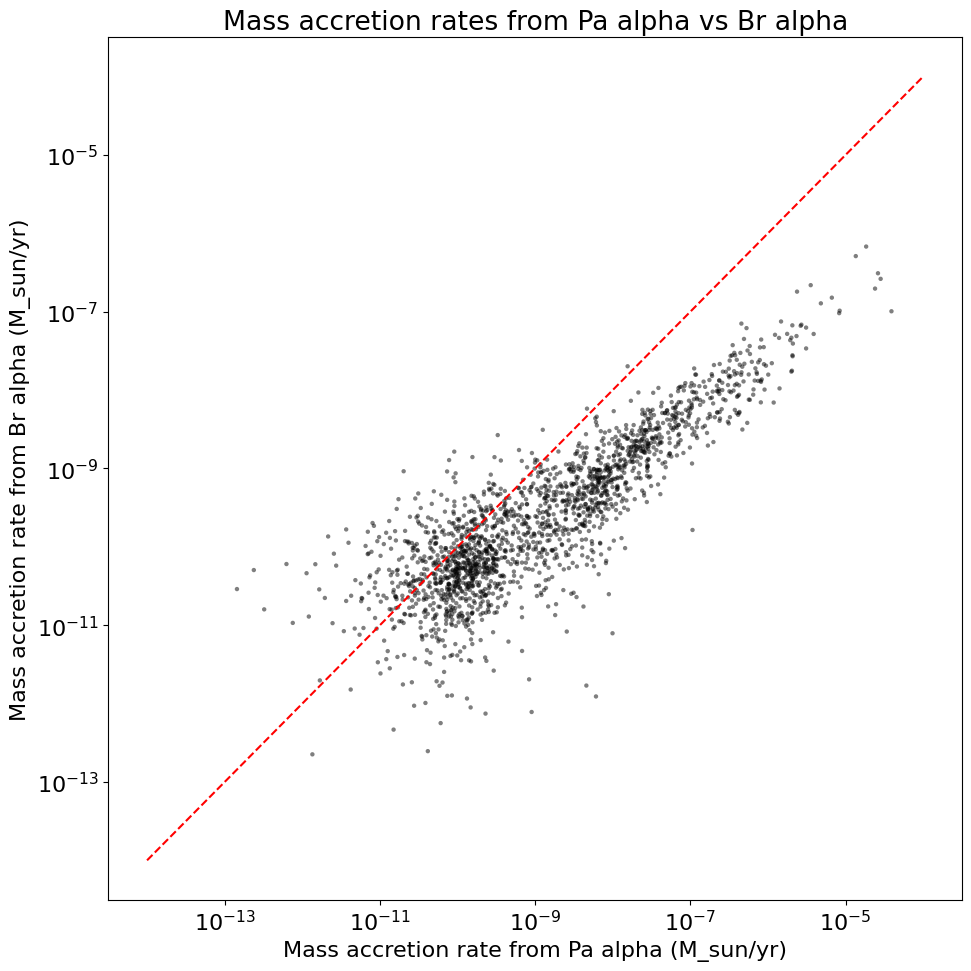

In [16]:
print(paa_excess)
# Jy -> erg/s/cm^2 at the wavelength of Pa alpha and Br alpha
paa_excess_ergscm2 = paa_excess * 1e-23 * (3e18 / wl_paa.to(u.AA).value**2) * u.erg/u.s/u.cm**2 *236.69
bra_excess_ergscm2 = bra_excess * 1e-23 * (3e18 / wl_bra.to(u.AA).value**2) * u.erg/u.s/u.cm**2 * 454.87 
L_paa_values = S_paa_to_lacc(paa_excess_ergscm2, distance=5.4*u.kpc, A_K=0.1*av_values)
L_bra_values = S_bra_to_lacc(bra_excess_ergscm2, distance=5.4*u.kpc, A_K=0.1*av_values)
print(L_paa_values)
macc_from_paa = macc(L_paa_values)
macc_from_bra = macc(L_bra_values)
# plot macc_from_paa vs macc_from_bra
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111)
ax.scatter(macc_from_paa.value, macc_from_bra.value, s=10, c='k',  alpha=0.5, edgecolor='none')
ax.set_xlabel('Mass accretion rate from Pa alpha (M_sun/yr)')
ax.set_ylabel('Mass accretion rate from Br alpha (M_sun/yr)')
ax.set_title('Mass accretion rates from Pa alpha vs Br alpha')
ax.set_xscale('log')
ax.set_yscale('log')
ax.plot([1e-14, 1e-4], [1e-14, 1e-4], color='r', linestyle='--')  # 1:1 line
plt.tight_layout()

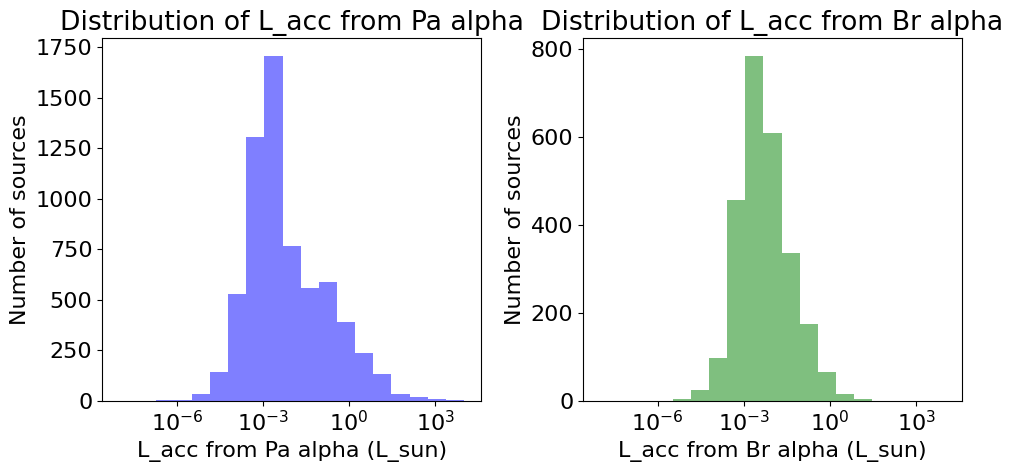

In [17]:
#histogram of Lacc from Pa alpha and Br alpha
fig = plt.figure(figsize=(10, 5))
ax1 = fig.add_subplot(121)
ax2 = fig.add_subplot(122)
logbin = np.logspace(-8,4,20)
ax1.hist(L_paa_values.value, bins=logbin, color='b', alpha=0.5)
ax1.set_xlabel('L_acc from Pa alpha (L_sun)')
ax1.set_ylabel('Number of sources')
ax1.set_title('Distribution of L_acc from Pa alpha')
ax1.set_xscale('log')
ax2.hist(L_bra_values.value, bins=logbin, color='g', alpha=0.5)
ax2.set_xlabel('L_acc from Br alpha (L_sun)')
ax2.set_ylabel('Number of sources')
ax2.set_title('Distribution of L_acc from Br alpha')
ax2.set_xscale('log')
plt.tight_layout()

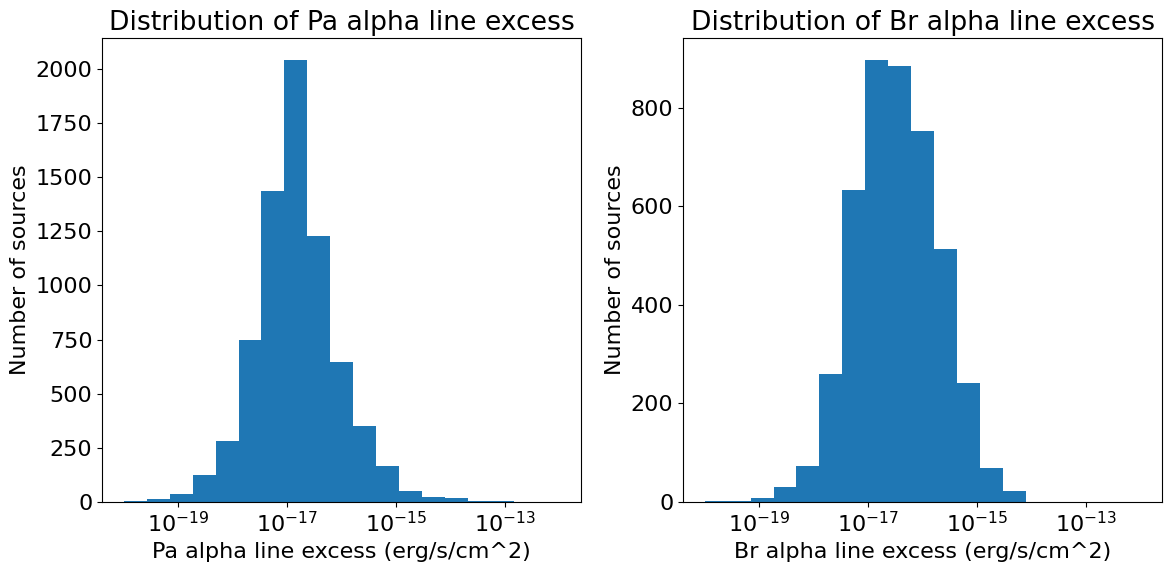

In [18]:
# histogram of paa_excess_ergscm2

fig = plt.figure(figsize=(12, 6))
ax = fig.add_subplot(121)
ax2 = fig.add_subplot(122)
bins = np.logspace(-20, -12, 20)
ax.hist(paa_excess_ergscm2.value, bins=bins)
ax.set_xlabel('Pa alpha line excess (erg/s/cm^2)')
ax.set_ylabel('Number of sources')
ax.set_title('Distribution of Pa alpha line excess')
ax.set_xscale('log')

ax2.hist(bra_excess_ergscm2.value, bins=bins)
ax2.set_xlabel('Br alpha line excess (erg/s/cm^2)')
ax2.set_ylabel('Number of sources')
ax2.set_title('Distribution of Br alpha line excess')
ax2.set_xscale('log')
plt.tight_layout()

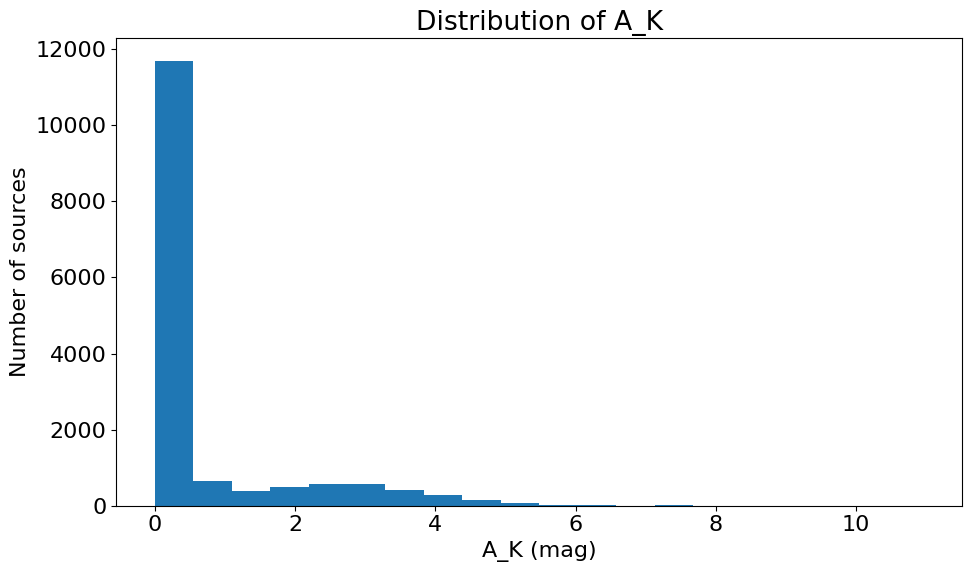

In [19]:
#histogram of A_K
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111)
ax.hist(av_values*0.1, bins=20)
ax.set_xlabel('A_K (mag)')
ax.set_ylabel('Number of sources')
ax.set_title('Distribution of A_K')
plt.tight_layout()  

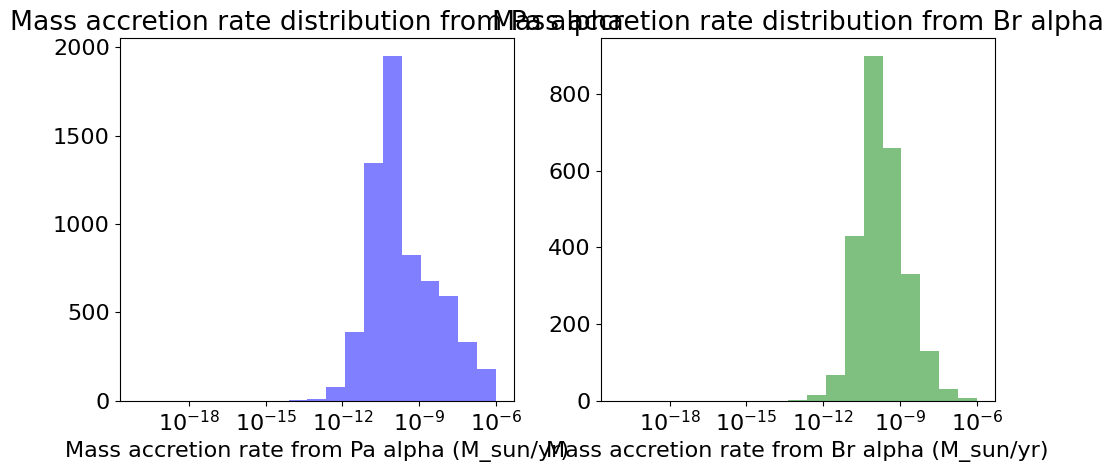

In [20]:
# histogram of macc_from_paa and macc_from_bra
fig = plt.figure(figsize=(10, 5))
ax1 = fig.add_subplot(121)
ax2 = fig.add_subplot(122)
ax1.hist(macc_from_paa.value, bins=np.logspace(-20, -6, 20), color='b', alpha=0.5)
ax2.hist(macc_from_bra.value, bins=np.logspace(-20, -6, 20), color='g', alpha=0.5)

ax1.set_xlabel('Mass accretion rate from Pa alpha (M_sun/yr)')
ax2.set_xlabel('Mass accretion rate from Br alpha (M_sun/yr)')
ax1.set_title('Mass accretion rate distribution from Pa alpha')
ax2.set_title('Mass accretion rate distribution from Br alpha')
ax1.set_xscale('log')
ax2.set_xscale('log')
plt.tight_layout()
plt.show()

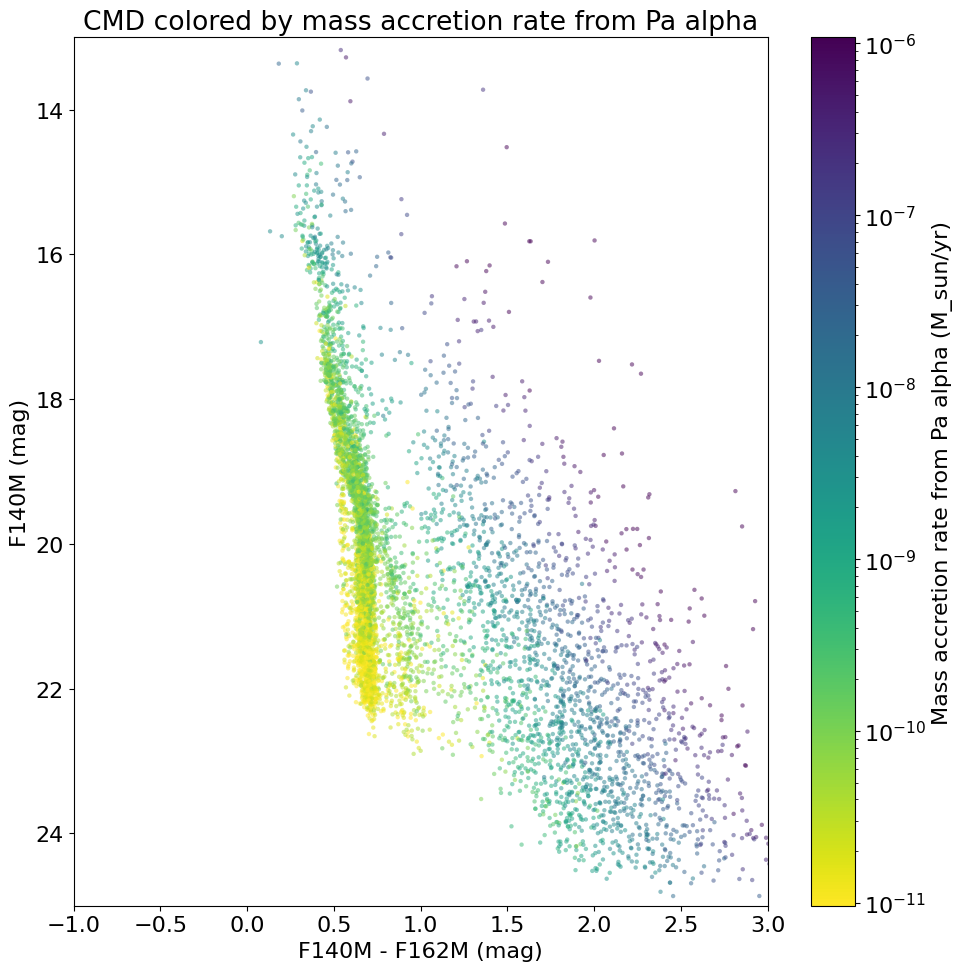

In [21]:
# plot color magnitude diagram with points colored by mass accretion rate from Pa alpha
from matplotlib.colors import LogNorm
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111)
cmap = plt.get_cmap('viridis_r')
# color coding in log scale
norm = LogNorm(vmin=np.nanpercentile(macc_from_paa.value, 10), vmax=np.nanpercentile(macc_from_paa.value, 99))
ax.scatter(color.value, magnitude.value, s=10, c=macc_from_paa.value, cmap=cmap, alpha=0.5, edgecolor='none', norm=norm)
ax.set_xlabel('F140M - F162M (mag)')
ax.set_ylabel('F140M (mag)')
ax.set_title('CMD colored by mass accretion rate from Pa alpha')
ax.set_xlim(-1,3)
ax.set_ylim(25, 13)
# add colorbar for mass accretion ratefrom Pa alpha
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label('Mass accretion rate from Pa alpha (M_sun/yr)')
plt.tight_layout()

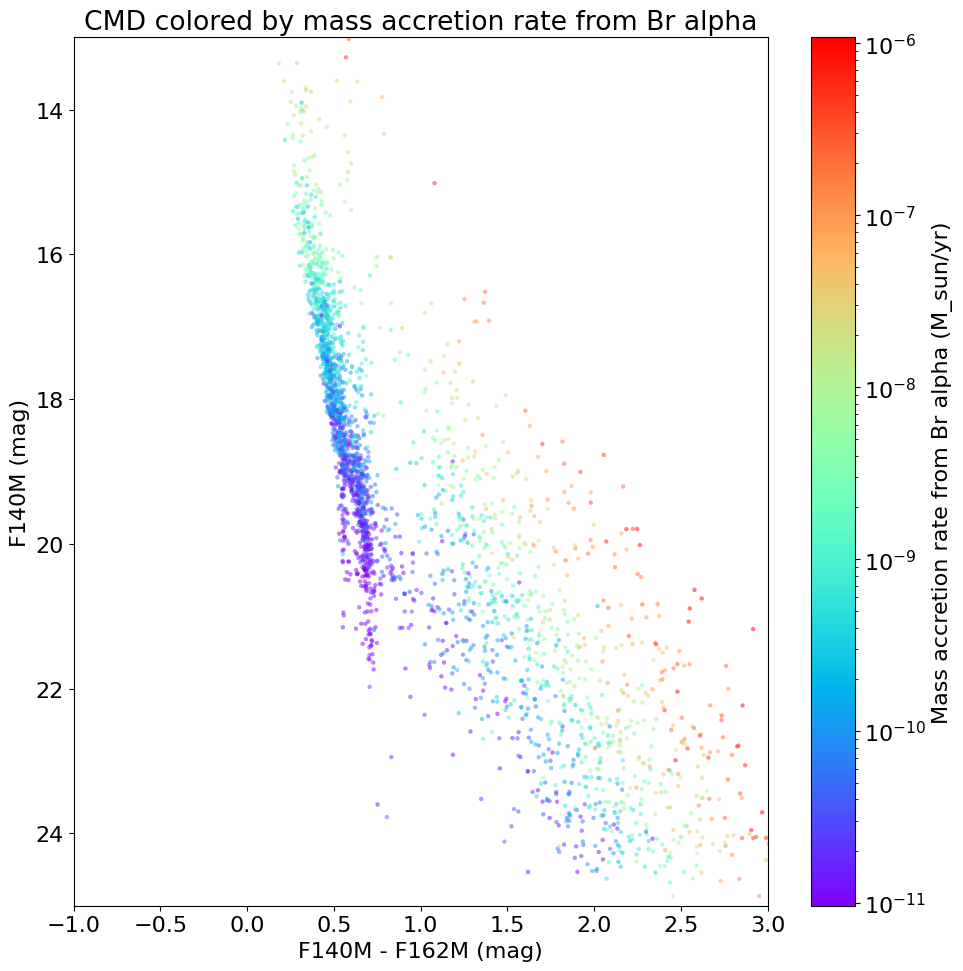

In [22]:
# plot color magnitude diagram with points colored by mass accretion rate from Pa alpha
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111)
cmap = plt.get_cmap('rainbow')

ax.scatter(color.value, magnitude.value, s=10, c=macc_from_bra.value, cmap=cmap, alpha=0.5, edgecolor='none', norm=LogNorm(vmin=np.nanpercentile(macc_from_bra.value, 10), vmax=np.nanpercentile(macc_from_bra.value, 99)))
ax.set_xlabel('F140M - F162M (mag)')
ax.set_ylabel('F140M (mag)')
ax.set_title('CMD colored by mass accretion rate from Br alpha')
ax.set_xlim(-1,3)
ax.set_ylim(25, 13)
# add colorbar for mass accretion ratefrom Pa alpha
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label('Mass accretion rate from Br alpha (M_sun/yr)')
plt.tight_layout()

In [23]:
# save catalogs of sources with high mass accretion rates
idx_high_macc_paa = macc_from_paa.value > 1e-7
idx_high_macc_bra = macc_from_bra.value > 1e-7
catalog_high_macc_paa = catalog[idx_high_macc_paa]
catalog_high_macc_bra = catalog[idx_high_macc_bra]
# save as fits file
catalog_high_macc_paa.write('/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/catalogs/catalog_high_macc_paa.fits', format='fits', overwrite=True)
catalog_high_macc_bra.write('/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/catalogs/catalog_high_macc_bra.fits', format='fits', overwrite=True)


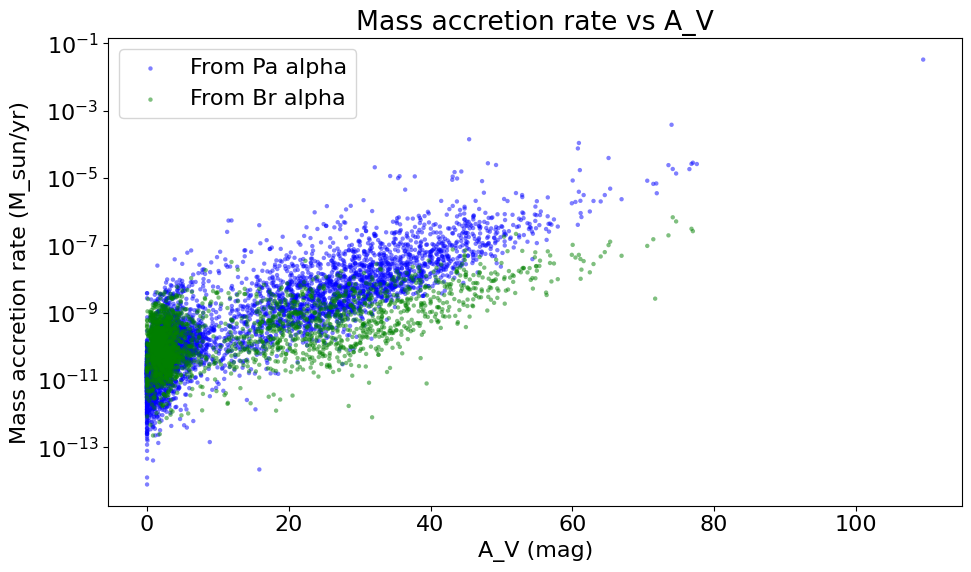

In [24]:
# dust extinction vs mass accretion rate
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111)
ax.scatter(av_values, macc_from_paa.value, s=10, c='b', alpha=0.5, edgecolor='none', label='From Pa alpha')
ax.scatter(av_values, macc_from_bra.value, s=10, c='g', alpha=0.5, edgecolor='none', label='From Br alpha')
ax.set_xlabel('A_V (mag)')
ax.set_ylabel('Mass accretion rate (M_sun/yr)')
ax.set_title('Mass accretion rate vs A_V')
ax.set_yscale('log')
ax.legend()
plt.tight_layout()
plt.show()

total number of sources with high mass accretion rate from Pa alpha: 961
total number of sources with high mass accretion rate from Pa alpha and finite fluxes in at least 4 NIRCam short filters: 961


'datfix' made the change 'Set DATE-BEG to '2025-05-06T16:37:42.537' from MJD-BEG.
Set DATE-AVG to '2025-05-06T16:59:22.406' from MJD-AVG.
Set DATE-END to '2025-05-06T17:21:22.408' from MJD-END'.
'obsfix' made the change 'Set OBSGEO-L to  -106.570116 from OBSGEO-[XYZ].
Set OBSGEO-B to   -25.271881 from OBSGEO-[XYZ].
Set OBSGEO-H to 1611441536.798 from OBSGEO-[XYZ]'.
'datfix' made the change 'Set DATE-BEG to '2025-05-06T13:57:33.059' from MJD-BEG.
Set DATE-AVG to '2025-05-06T14:19:06.870' from MJD-AVG.
Set DATE-END to '2025-05-06T14:41:02.194' from MJD-END'.
'obsfix' made the change 'Set OBSGEO-L to  -106.647326 from OBSGEO-[XYZ].
Set OBSGEO-B to   -25.220336 from OBSGEO-[XYZ].
Set OBSGEO-H to 1610512569.543 from OBSGEO-[XYZ]'.
'datfix' made the change 'Set DATE-BEG to '2025-05-06T14:49:48.239' from MJD-BEG.
Set DATE-AVG to '2025-05-06T15:11:59.611' from MJD-AVG.
Set DATE-END to '2025-05-06T15:35:36.878' from MJD-END'.
'obsfix' made the change 'Set OBSGEO-L to  -106.622086 from OBSGEO-[X

Number of sources expected to be detected in at least 5 Roman filters: 491
Number of sources expected to be detected in all Roman filters: 184
Number of sources expected to be saturated in at least 5 Roman filters: 0
Number of sources expected to be saturated in all Roman filters: 0


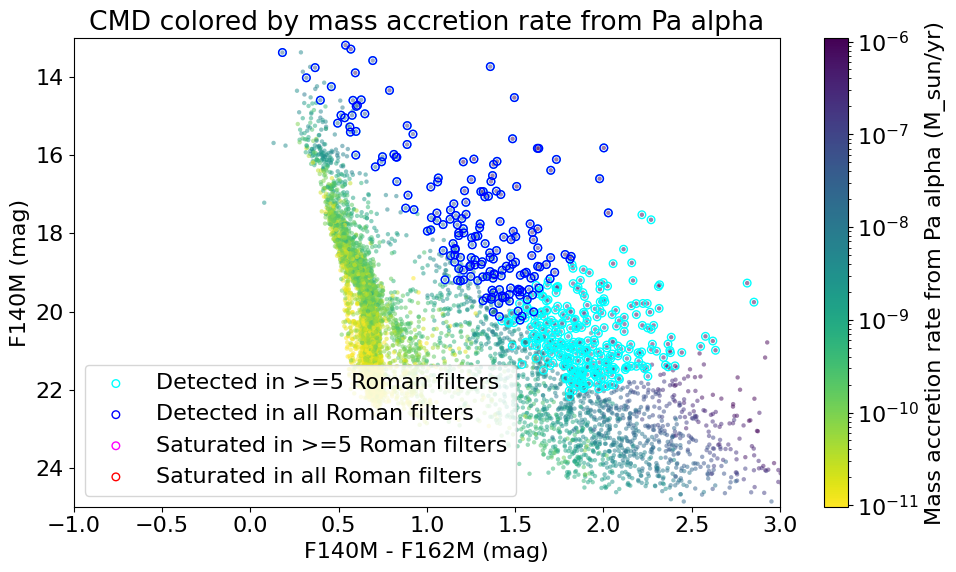

In [25]:
from astropy.table import Table
from astroquery.svo_fps import SvoFps
from scipy.integrate import simpson, trapezoid


def check_roman_sensivity(catalog, idx, filters = ['f140m', 'f162m', 'f182m', 'f187n', 'f210m', 'f335m', 'f360m', 'f405n', 'f410m', 'f480m', 'f560w', 'f770w', 'f1000w', 'f1280w', 'f2100w'],
roman_limits = [24.4+0.75, 24.1+0.75, 24.1+0.75, 24.0+0.75, 23.9+0.75, 23.3+0.75, 23.0+0.75], sat_limits = [14.6, 14.2, 14.2, 14.0, 13.9, 13.2, 13.1 ],
):
    
    
    #extrapolate the flux_yso to 0.4micron
    
    flux_0p4 = (catalog['flux_fit_f140m'][idx] - catalog['flux_fit_f162m'][idx])/(1.62-1.40) * (0.4-1.40) + catalog['flux_fit_f140m'][idx] #linear extrapolation

    finite_filters = [f for f in filters if np.isfinite(catalog['flux_fit_'+f][idx])]
    finite_nircam_short_filters = [f for f in finite_filters if f in ['f140m', 'f162m', 'f182m', 'f187n', 'f210m']]

    if len(finite_nircam_short_filters) >= 4:
        # Get wavelengths and fluxes for the finite filters
        wavelengths = np.array([int(f[1:-1])/100 for f in finite_nircam_short_filters])  # in microns

        fluxes_jy = []
        for f in finite_nircam_short_filters:
            ww = WCS(fits.getheader(image_filenames[f], ext=('SCI', 1)))
            fluxes_jy.append((catalog['flux_fit_'+f][idx]* u.MJy/u.sr * ww.proj_plane_pixel_area()).to(u.Jy).value)
        fluxes_jy = np.array(fluxes_jy)
        # Perform linear fit in log-log space
        log_wavelengths = np.log10(wavelengths)
        log_fluxes = np.log10(fluxes_jy)
        
        # Fit a line: log(flux) = m * log(wavelength) + b
        coeffs = np.polyfit(log_wavelengths, log_fluxes, 1)
        m, b = coeffs[0], coeffs[1]
        
        # Extrapolate to desired wavelengths
        target_wavelengths = np.linspace(0.4, 2.5, 100)  # from 0.4 to 2.5 microns
        log_target_wavelengths = np.log10(target_wavelengths)
        log_extrapolated_fluxes = m * log_target_wavelengths + b
        extrapolated_fluxes = 10**log_extrapolated_fluxes
        
        # Store or return the extrapolated SED
        sed_wavelengths = target_wavelengths
        sed_fluxes = extrapolated_fluxes
    else:
        raise ValueError("Not enough finite NIRCam short filters to perform extrapolation")


    


    roman_filters = SvoFps.get_filter_list('Roman')
    isdetected = np.zeros(len(roman_limits), dtype=bool)
    issaturated = np.zeros(len(roman_limits), dtype=bool)
    for ii, filter_id in enumerate(['Roman/WFI.F062', 'Roman/WFI.F087', 'Roman/WFI.F106', 'Roman/WFI.F129', 'Roman/WFI.F158', 'Roman/WFI.F184', 'Roman/WFI.F213']):
        
        filter_data = roman_filters[roman_filters['filterID'].astype(str) == filter_id]
        wavelength_table = SvoFps.get_transmission_data(filter_id)
      
        waves = wavelength_table['Wavelength'].value  # Convert to numpy array
        trans = wavelength_table['Transmission'].value  # Convert to numpy array

        # Interpolate the extrapolated SED onto the filter's wavelength grid
        # Convert wavelengths from microns to Angstroms for interpolation
        interp_fluxes = np.interp(waves, sed_wavelengths * 1e4, sed_fluxes)
        
        # Calculate the expected flux in the Roman filter using scipy.integrate
        # Use Simpson's rule for better accuracy, or trapezoid for trapezoidal integration
        expected_flux = simpson(interp_fluxes * trans, x=waves) / simpson(trans, x=waves)
        # Alternative: expected_flux = trapezoid(interp_fluxes * trans, x=waves) / trapezoid(trans, x=waves)
        #print(f'Expected flux in {filter_id}: {expected_flux} Jy')
        # convert it to magnitude using the zero point of the Roman filter
        roman_filters.add_index('filterID')
        
        expected_mag = -2.5 * np.log10(expected_flux / 3631)  # AB magnitude
        #print(f'Expected magnitude in {filter_id}: {expected_mag}')
        
        if expected_mag < roman_limits[ii]:
            isdetected[ii] = True
        if expected_mag < sat_limits[ii]:
            issaturated[ii] = True
            
    return isdetected, issaturated




# get the source lists that have mass accretion rate from Pa alpha > 1e-8M/yr and finite fluxes in at least 4 NIRCam short filters
# get the source lists that have mass accretion rate from Pa alpha > 1e-8M/yr and finite fluxes in at least 4 NIRCam short filters
idx_high_macc_paa = macc_from_paa.value > 1e-8

# Create boolean array for each filter
idx_finite_nircam_short = np.array([np.isfinite(catalog['flux_fit_'+f]) for f in ['f140m', 'f162m', 'f182m', 'f187n', 'f210m']])

# Sum across filters to count how many finite values each source has
idx_finite_nircam_short_sum = idx_finite_nircam_short.sum(axis=0)

# Select sources with high mass accretion and at least 4 finite NIRCam short filters
idx_good = np.where(idx_high_macc_paa & (idx_finite_nircam_short_sum >= 4))[0]

print('total number of sources with high mass accretion rate from Pa alpha:', idx_high_macc_paa.sum())
print('total number of sources with high mass accretion rate from Pa alpha and finite fluxes in at least 4 NIRCam short filters:', len(idx_good))   


detected_gt_5 = 0
detected_all = 0
saturated_gt_5 = 0
saturated_all = 0

fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111)
idx_detected_gt_5 = []
idx_detected_all = []
idx_saturated_gt_5 = []
idx_saturated_all = []
for idx in idx_good:
    isdetected, issaturated = check_roman_sensivity(catalog, idx)
    if isdetected.sum() >= 5:
        detected_gt_5 += 1
        idx_detected_gt_5.append(idx)
    if isdetected.sum() == len(isdetected):
        detected_all += 1
        idx_detected_all.append(idx)
    if issaturated.sum() >= 5:
        saturated_gt_5 += 1
        idx_saturated_gt_5.append(idx)
    if issaturated.sum() == len(issaturated):
        saturated_all += 1
        idx_saturated_all.append(idx)
        
print(f"Number of sources expected to be detected in at least 5 Roman filters: {detected_gt_5}")
print(f"Number of sources expected to be detected in all Roman filters: {detected_all}")
print(f"Number of sources expected to be saturated in at least 5 Roman filters: {saturated_gt_5}")
print(f"Number of sources expected to be saturated in all Roman filters: {saturated_all}")

cmap = plt.get_cmap('viridis_r')
# color coding in log scale
norm = LogNorm(vmin=np.nanpercentile(macc_from_paa.value, 10), vmax=np.nanpercentile(macc_from_paa.value, 99))
ax.scatter(color.value, magnitude.value, s=10, c=macc_from_paa.value, cmap=cmap, alpha=0.5, edgecolor='none', norm=norm)
ax.set_xlabel('F140M - F162M (mag)')
ax.set_ylabel('F140M (mag)')
ax.set_title('CMD colored by mass accretion rate from Pa alpha')
ax.set_xlim(-1,3)
ax.set_ylim(25, 13)
# add colorbar for mass accretion ratefrom Pa alpha
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label('Mass accretion rate from Pa alpha (M_sun/yr)')
plt.tight_layout()


ax.scatter(color.value[idx_detected_gt_5], magnitude.value[idx_detected_gt_5], s=30, facecolors='none', edgecolors='cyan', label='Detected in >=5 Roman filters')
ax.scatter(color.value[idx_detected_all], magnitude.value[idx_detected_all], s=30, facecolors='none', edgecolors='blue', label='Detected in all Roman filters')
ax.scatter(color.value[idx_saturated_gt_5], magnitude.value[idx_saturated_gt_5], s=30, facecolors='none', edgecolors='magenta', label='Saturated in >=5 Roman filters')
ax.scatter(color.value[idx_saturated_all], magnitude.value[idx_saturated_all], s=30, facecolors='none', edgecolors='red', label='Saturated in all Roman filters')
ax.legend(loc='lower left')

1.3 82.291
1.649 82.291


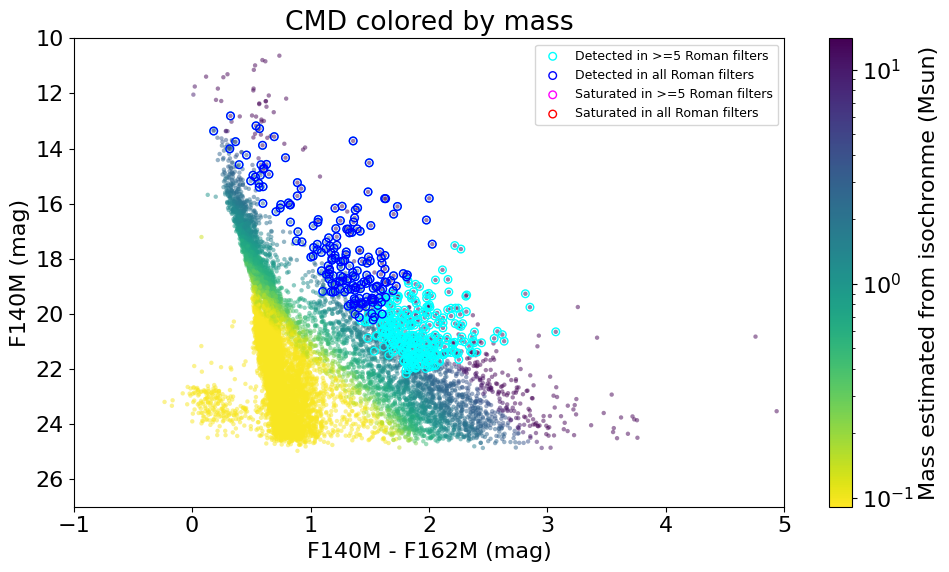

In [26]:
# make the cmd but cmd points are color-coded by mass
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111)
cmap = plt.get_cmap('viridis_r')
# color coding in log scale
norm = LogNorm(vmin=np.nanpercentile(mass_values, 10), vmax=np.nanpercentile(mass_values, 99))
ax.scatter(color.value, magnitude.value, s=10, c=mass_values, cmap=cmap, alpha=0.5, edgecolor='none', norm=norm)
print(np.nanmin(mass_values[idx_detected_gt_5]), np.nanmax(mass_values[idx_detected_gt_5]))
print(np.nanmin(mass_values[idx_detected_all]), np.nanmax(mass_values[idx_detected_all]))
ax.set_xlabel('F140M - F162M (mag)')
ax.set_ylabel('F140M (mag)')
ax.set_title('CMD colored by mass')
ax.set_xlim(-1,5)
ax.set_ylim(27, 10)
# add colorbar for mass accretion ratefrom Pa alpha
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label('Mass estimated from isochronme (Msun)')
plt.tight_layout()


ax.scatter(color.value[idx_detected_gt_5], magnitude.value[idx_detected_gt_5], s=30, facecolors='none', edgecolors='cyan', label='Detected in >=5 Roman filters')
ax.scatter(color.value[idx_detected_all], magnitude.value[idx_detected_all], s=30, facecolors='none', edgecolors='blue', label='Detected in all Roman filters')
ax.scatter(color.value[idx_saturated_gt_5], magnitude.value[idx_saturated_gt_5], s=30, facecolors='none', edgecolors='magenta', label='Saturated in >=5 Roman filters')
ax.scatter(color.value[idx_saturated_all], magnitude.value[idx_saturated_all], s=30, facecolors='none', edgecolors='red', label='Saturated in all Roman filters')
ax.legend(loc='upper right', fontsize=9)

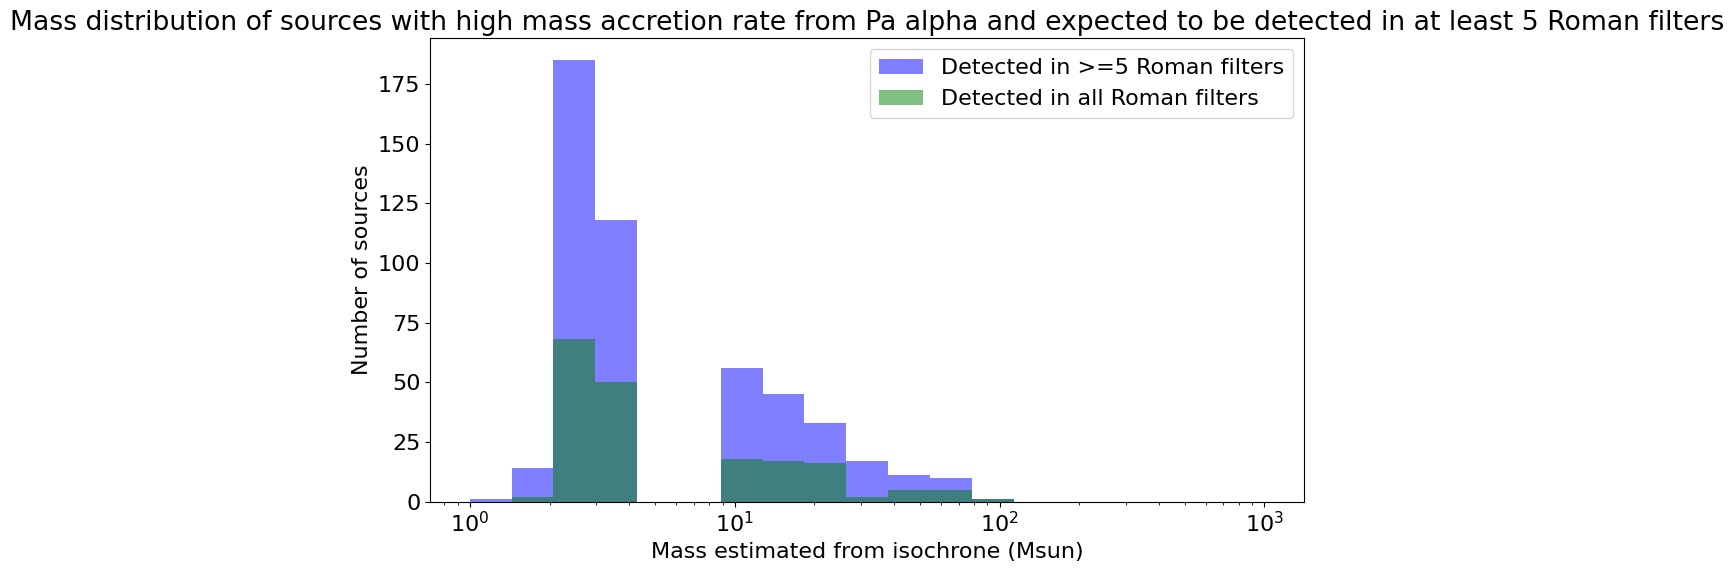

In [27]:
#plot histogram of mass of those sources with high mass accretion rate from Pa alpha and expected to be detected in at least 5 Roman filters
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111)
ax.hist(mass_values[idx_detected_gt_5], bins=np.logspace(0, 3, 20), color='b', alpha=0.5, label='Detected in >=5 Roman filters')
ax.hist(mass_values[idx_detected_all], bins=np.logspace(0, 3, 20), color='g', alpha=0.5, label='Detected in all Roman filters')
ax.set_xlabel('Mass estimated from isochrone (Msun)')
ax.set_ylabel('Number of sources')
ax.set_title('Mass distribution of sources with high mass accretion rate from Pa alpha and expected to be detected in at least 5 Roman filters')
ax.set_xscale('log')
ax.legend(loc='upper right')
plt.tight_layout()

'datfix' made the change 'Set DATE-BEG to '2025-05-06T16:37:42.537' from MJD-BEG.
Set DATE-AVG to '2025-05-06T16:59:22.406' from MJD-AVG.
Set DATE-END to '2025-05-06T17:21:22.408' from MJD-END'.
'obsfix' made the change 'Set OBSGEO-L to  -106.570116 from OBSGEO-[XYZ].
Set OBSGEO-B to   -25.271881 from OBSGEO-[XYZ].
Set OBSGEO-H to 1611441536.798 from OBSGEO-[XYZ]'.
'datfix' made the change 'Set DATE-BEG to '2025-05-06T13:57:33.059' from MJD-BEG.
Set DATE-AVG to '2025-05-06T14:19:06.870' from MJD-AVG.
Set DATE-END to '2025-05-06T14:41:02.194' from MJD-END'.
'obsfix' made the change 'Set OBSGEO-L to  -106.647326 from OBSGEO-[XYZ].
Set OBSGEO-B to   -25.220336 from OBSGEO-[XYZ].
Set OBSGEO-H to 1610512569.543 from OBSGEO-[XYZ]'.
'datfix' made the change 'Set DATE-BEG to '2025-05-06T14:49:48.239' from MJD-BEG.
Set DATE-AVG to '2025-05-06T15:11:59.611' from MJD-AVG.
Set DATE-END to '2025-05-06T15:35:36.878' from MJD-END'.
'obsfix' made the change 'Set OBSGEO-L to  -106.622086 from OBSGEO-[X

Text(0, 0.5, 'F140M (mag)')

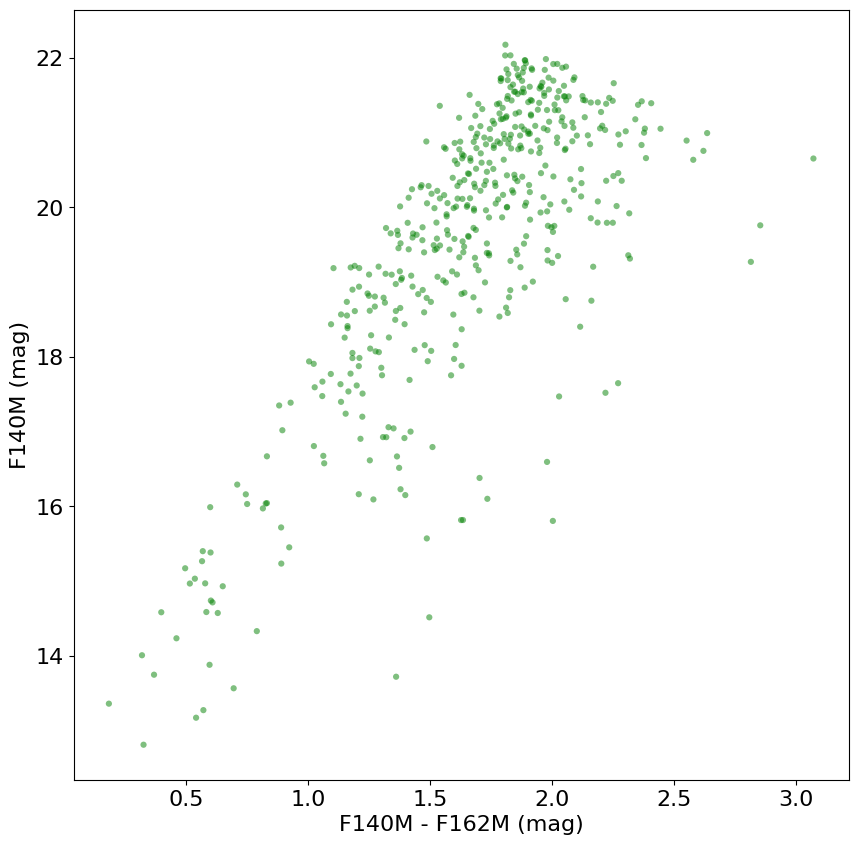

In [28]:
# plot cmd of the sources expected to be detected in at least 5 Roman filters and also saturated in at least 5 Roman filters
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111)
cmap = plt.get_cmap('viridis_r')
for idx in idx_good:
    isdetected, issaturated = check_roman_sensivity(catalog, idx)
    if isdetected.sum() >= 5 and issaturated.sum() >= 5:
        ax.scatter(color.value[idx], magnitude.value[idx], s=20, c='r', alpha=0.5, edgecolor='none', label='Detected in >=5 Roman filters and saturated in >=5 Roman filters')
    elif isdetected.sum() >= 5:
        ax.scatter(color.value[idx], magnitude.value[idx], s=20, c='g', alpha=0.5, edgecolor='none', label='Detected in >=5 Roman filters')
    elif issaturated.sum() >= 5: 
        ax.scatter(color.value[idx], magnitude.value[idx], s=20, c='b', alpha=0.5, edgecolor='none', label='Saturated in >=5 Roman filters')
ax.set_xlabel('F140M - F162M (mag)')
ax.set_ylabel('F140M (mag)')

total number of sources with finite flux at F480M: 6801
total number of sources: 25940


(27.0, 10.0)

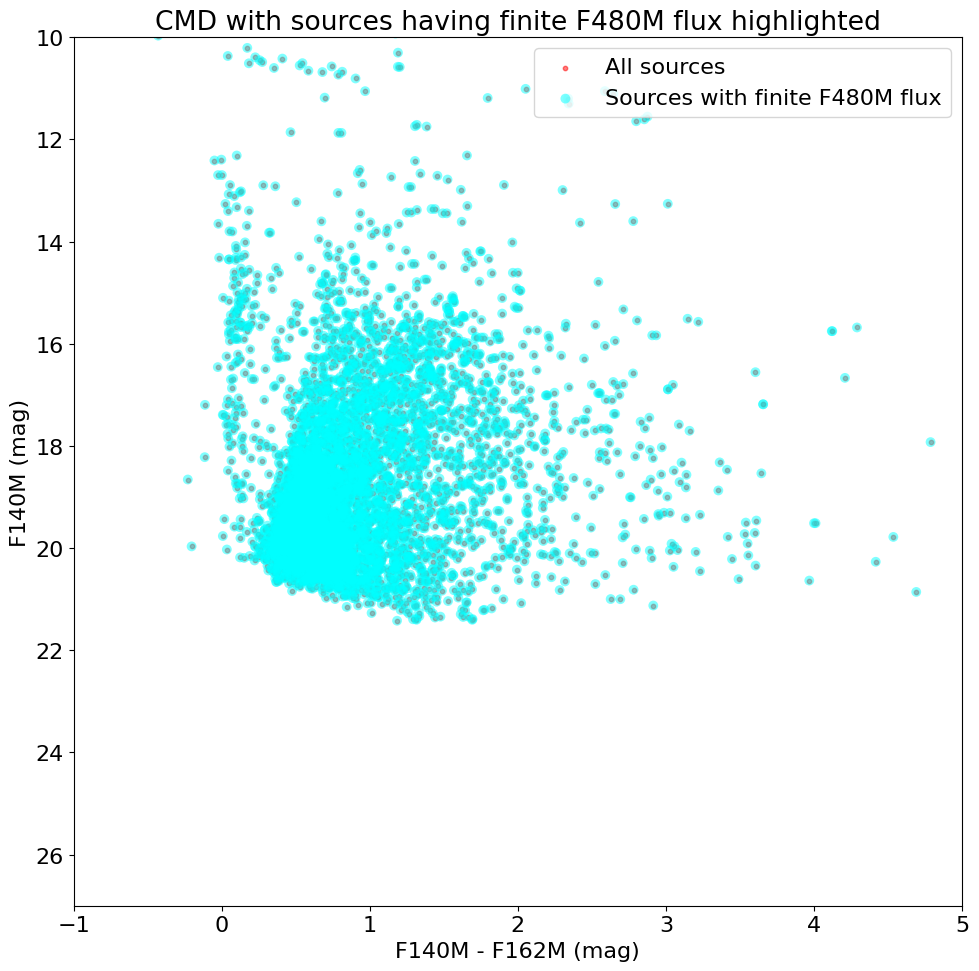

In [40]:
# Now plot the CMD but mark the sources that have finite flux at F480M
print('total number of sources with finite flux at F480M:', np.isfinite(catalog['flux_fit_f480m']).sum())
print('total number of sources:', len(catalog))
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111)
idx_finite_f480m = np.isfinite(catalog['flux_fit_f480m'])
ax.scatter(color.value, magnitude.value, s=10, c='r', alpha=0.5, label='All sources')
ax.scatter(color.value[idx_finite_f480m], magnitude.value[idx_finite_f480m], s=50, c='cyan', alpha=0.5, edgecolor='none', label='Sources with finite F480M flux')
ax.set_xlabel('F140M - F162M (mag)')
ax.set_ylabel('F140M (mag)')
ax.set_title('CMD with sources having finite F480M flux highlighted')
ax.legend(loc='upper right')
plt.tight_layout()
ax.set_xlim(-1,5)
ax.set_ylim(27, 10)

### F140M - F162M vs F140M color marked with F405N-F410M>0

Number of points with f405n-f410m > 0: 275
1.4 um 1.62 um 1.4 um
1.4 um 1.62 um 1.4 um
7.0412946428571415 5.4357638888888875 7.0412946428571415


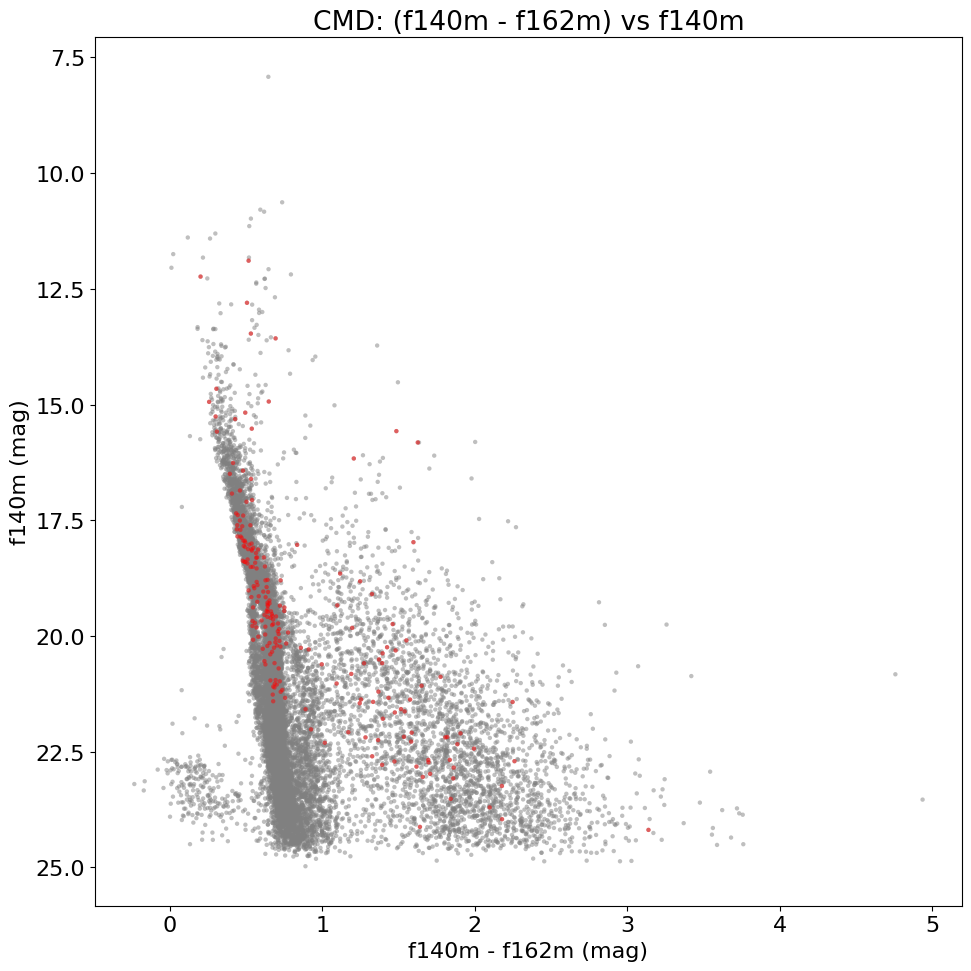

In [30]:
# plot f140m-f162m color coded by f405n-f410m color
color = filters['f140m'][0] - filters['f162m'][0]
color_for_points = filters['f405n'][0] - filters['f410m'][0]

magnitude = filters['f140m'][0]


# Create plot
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111)

#hb = ax.hexbin(color_valid, mag_valid, gridsize=100, cmap='inferno', mincnt=1, bins='log')
#cb = fig.colorbar(hb, ax=ax, label='log(N)')
cmap = plt.get_cmap('inferno')
ax.scatter(color.value, magnitude.value, s=10, c='gray',  alpha=0.5, edgecolor='none')
color_cut = np.where(color_for_points.value > 0)[0]
print(f"Number of points with f405n-f410m > 0: {len(color_cut)}")
ax.scatter(color.value[color_cut], magnitude.value[color_cut], s=10, c='red', alpha=0.5, edgecolor='none')
ax.set_xlabel('f140m - f162m (mag)')
ax.set_ylabel('f140m (mag)')
ax.set_title(f'CMD: (f140m - f162m) vs f140m')
ax.invert_yaxis()  # Invert y-axis for magnitude

# Add extinction vector
plot_extvec_cmd(ax, color1=('f140m', 'f162m'), mag1=('f140m',), 
                ext=ext, extvec_scale=30, color='r', 
                color1_data=color, mag1_data=magnitude)
#add colorbar for the color coding

plt.tight_layout()
#plt.savefig(f'{imgsavedir}cmd_{f1}_{f2}_vs_{mag_filter}.png', dpi=150)
plt.show()

### F140M - F162M vs F140M color marked with F187N-F182M>0

Number of points with f405n-f410m > 0: 205
1.4 um 1.62 um 1.4 um
1.4 um 1.62 um 1.4 um
7.0412946428571415 5.4357638888888875 7.0412946428571415


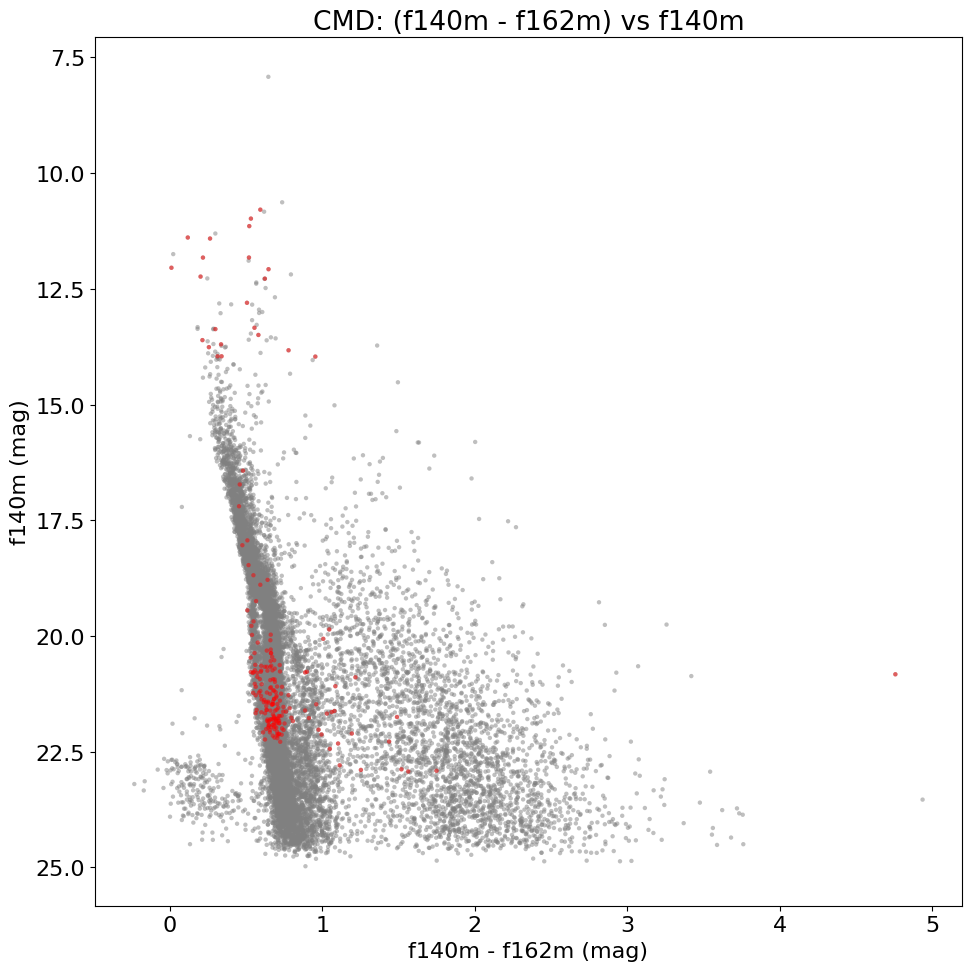

In [31]:
# plot f140m-f162m color coded by f405n-f410m color
color = filters['f140m'][0] - filters['f162m'][0]
color_for_points = filters['f187n'][0] - filters['f182m'][0]

magnitude = filters['f140m'][0]


# Create plot
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111)

#hb = ax.hexbin(color_valid, mag_valid, gridsize=100, cmap='inferno', mincnt=1, bins='log')
#cb = fig.colorbar(hb, ax=ax, label='log(N)')
cmap = plt.get_cmap('inferno')
ax.scatter(color.value, magnitude.value, s=10, c='gray',  alpha=0.5, edgecolor='none')
color_cut = np.where(color_for_points.value > 0)[0]
print(f"Number of points with f405n-f410m > 0: {len(color_cut)}")
ax.scatter(color.value[color_cut], magnitude.value[color_cut], s=10, c='red', alpha=0.5, edgecolor='none')
ax.set_xlabel('f140m - f162m (mag)')
ax.set_ylabel('f140m (mag)')
ax.set_title(f'CMD: (f140m - f162m) vs f140m')
ax.invert_yaxis()  # Invert y-axis for magnitude

# Add extinction vector
plot_extvec_cmd(ax, color1=('f140m', 'f162m'), mag1=('f140m',), 
                ext=ext, extvec_scale=30, color='r', 
                color1_data=color, mag1_data=magnitude)
#add colorbar for the color coding

plt.tight_layout()
#plt.savefig(f'{imgsavedir}cmd_{f1}_{f2}_vs_{mag_filter}.png', dpi=150)
plt.show()

### F360M - F480M vs F360M color marked with F405N-F410M>0

Number of points with f405n-f410m > 0: 275
3.6 um 4.8 um 3.6 um
3.6 um 4.8 um 3.6 um
1.6323076923076927 0.69 1.6323076923076927


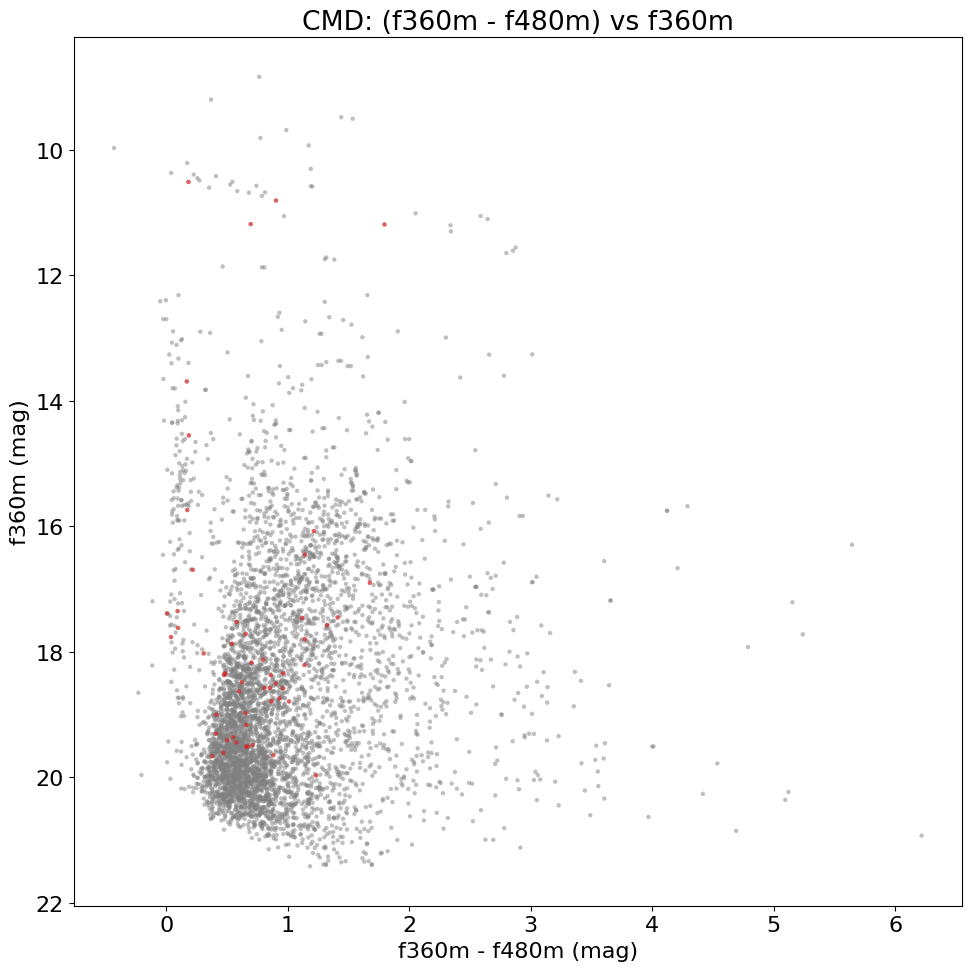

In [32]:
# plot f360m-f480m color coded by f405n-f410m color
color = filters['f360m'][0] - filters['f480m'][0]
color_for_points = filters['f405n'][0] - filters['f410m'][0]

magnitude = filters['f360m'][0]


# Create plot
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111)

#hb = ax.hexbin(color_valid, mag_valid, gridsize=100, cmap='inferno', mincnt=1, bins='log')
#cb = fig.colorbar(hb, ax=ax, label='log(N)')
cmap = plt.get_cmap('inferno')
ax.scatter(color.value, magnitude.value, s=10, c='gray',  alpha=0.5, edgecolor='none')
color_cut = np.where(color_for_points.value > 0)[0]
print(f"Number of points with f405n-f410m > 0: {len(color_cut)}")
ax.scatter(color.value[color_cut], magnitude.value[color_cut], s=10, c='red', alpha=0.5, edgecolor='none')
ax.set_xlabel('f360m - f480m (mag)')
ax.set_ylabel('f360m (mag)')
ax.set_title(f'CMD: (f360m - f480m) vs f360m')
ax.invert_yaxis()  # Invert y-axis for magnitude

# Add extinction vector
plot_extvec_cmd(ax, color1=('f360m', 'f480m'), mag1=('f360m',), 
                ext=ext, extvec_scale=30, color='r', 
                color1_data=color, mag1_data=magnitude)
#add colorbar for the color coding

plt.tight_layout()
#plt.savefig(f'{imgsavedir}cmd_{f1}_{f2}_vs_{mag_filter}.png', dpi=150)
plt.show()

### F360M - F480M vs F360M color marked with F405N-F410M>0 and F140M-F162M>1.3


Number of points with f140m-f162m > 1: 3205
Number of points with f405n-f410m > 0: 62
3.6 um 4.8 um 3.6 um
3.6 um 4.8 um 3.6 um
1.6323076923076927 0.69 1.6323076923076927


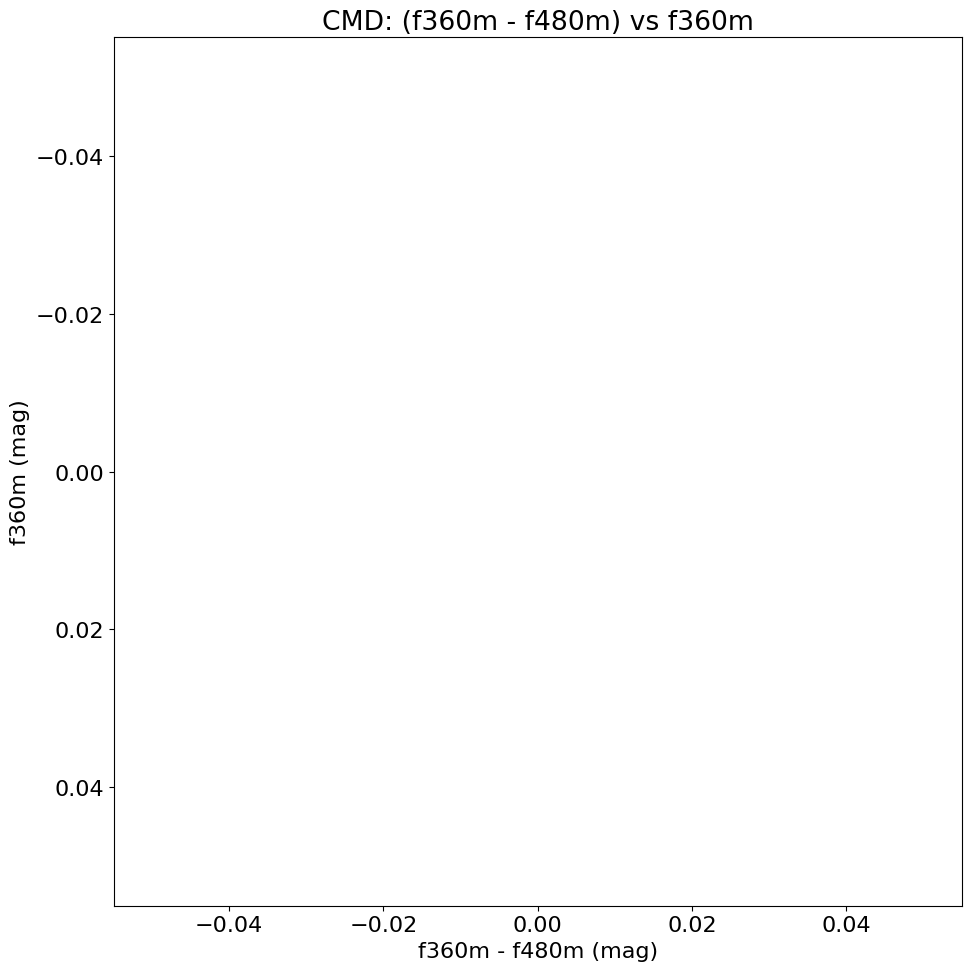

In [33]:
# plot f360m-f480m color coded by f405n-f410m color
color = filters['f360m'][0] - filters['f480m'][0]
color_for_points = filters['f405n'][0] - filters['f410m'][0]

magnitude = filters['f360m'][0]

f140f162 = filters['f140m'][0] - filters['f162m'][0]
idx = np.where((f140f162.value>1.))[0]
print(f"Number of points with f140m-f162m > 1: {len(idx)}")
# Create plot
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111)

#hb = ax.hexbin(color_valid, mag_valid, gridsize=100, cmap='inferno', mincnt=1, bins='log')
#cb = fig.colorbar(hb, ax=ax, label='log(N)')
cmap = plt.get_cmap('inferno')
ax.scatter(color.value[idx], magnitude.value[idx], s=10, c='gray',  alpha=0.5, edgecolor='none')
color_cut = np.where(color_for_points.value[idx] > 0)[0]
print(f"Number of points with f405n-f410m > 0: {len(color_cut)}")
ax.scatter(color.value[idx][color_cut], magnitude.value[idx][color_cut], s=10, c='red', alpha=0.5, edgecolor='none')
ax.set_xlabel('f360m - f480m (mag)')
ax.set_ylabel('f360m (mag)')
ax.set_title(f'CMD: (f360m - f480m) vs f360m')
ax.invert_yaxis()  # Invert y-axis for magnitude

# Add extinction vector
plot_extvec_cmd(ax, color1=('f360m', 'f480m'), mag1=('f360m',), 
                ext=ext, extvec_scale=30, color='r', 
                color1_data=color, mag1_data=magnitude)
#add colorbar for the color coding

plt.tight_layout()
#plt.savefig(f'{imgsavedir}cmd_{f1}_{f2}_vs_{mag_filter}.png', dpi=150)
plt.show()

Number of points with f187n-f182m > 0: 205
3.6 um 4.8 um 3.6 um
3.6 um 4.8 um 3.6 um
1.6323076923076927 0.69 1.6323076923076927


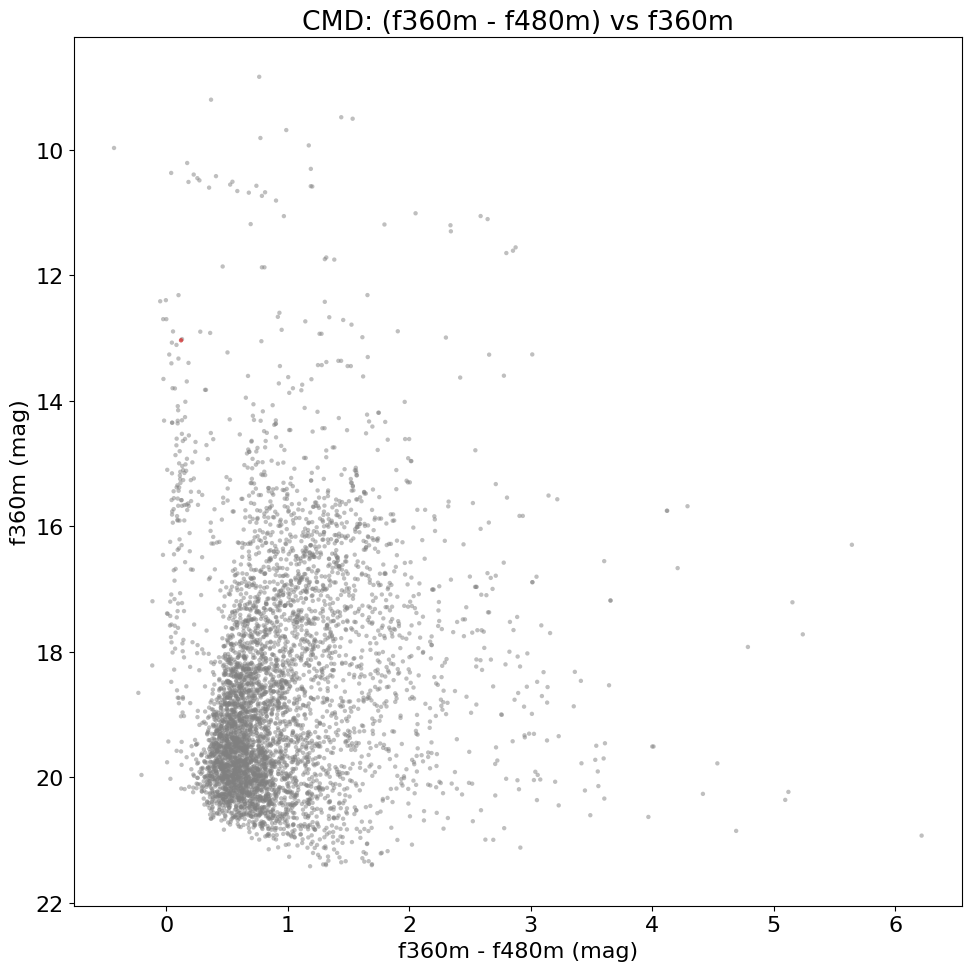

In [34]:
# plot f360m-f480m color coded by f405n-f410m color
color = filters['f360m'][0] - filters['f480m'][0]
color_for_points = filters['f187n'][0] - filters['f182m'][0]

magnitude = filters['f360m'][0]


# Create plot
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111)

#hb = ax.hexbin(color_valid, mag_valid, gridsize=100, cmap='inferno', mincnt=1, bins='log')
#cb = fig.colorbar(hb, ax=ax, label='log(N)')
cmap = plt.get_cmap('inferno')
ax.scatter(color.value, magnitude.value, s=10, c='gray',  alpha=0.5, edgecolor='none')
color_cut = np.where(color_for_points.value > 0)[0]
print(f"Number of points with f187n-f182m > 0: {len(color_cut)}")
ax.scatter(color.value[color_cut], magnitude.value[color_cut], s=10, c='red', alpha=0.5, edgecolor='none')
ax.set_xlabel('f360m - f480m (mag)')
ax.set_ylabel('f360m (mag)')
ax.set_title(f'CMD: (f360m - f480m) vs f360m')
ax.invert_yaxis()  # Invert y-axis for magnitude

# Add extinction vector
plot_extvec_cmd(ax, color1=('f360m', 'f480m'), mag1=('f360m',), 
                ext=ext, extvec_scale=30, color='r', 
                color1_data=color, mag1_data=magnitude)
#add colorbar for the color coding

plt.tight_layout()
#plt.savefig(f'{imgsavedir}cmd_{f1}_{f2}_vs_{mag_filter}.png', dpi=150)
plt.show()